# Decision Tree : 결정 트리

In [65]:
# 타이타닉 데이터 불러오기

import seaborn as sns

data = sns.load_dataset("titanic")
data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [2]:
# data라는 변수 안에 넣어둔 타이타닉 

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [66]:
# 불필요한 컬럼을 drop 으로 제거하는 과정
prep_data = data.drop(columns=["alive", "who", "adult_male", "class", "embark_town"])

# 결측치가 너무 많은 컬럼 제거
# axis = 1 이면 컬럼을 의미함, 0이면 행을 의미
# inplace 는 원본 데이터프레임을 바로 변경시켜주는 코드이다 즉, 현재 deck 컬럼을 지워줬으니 바로
# 지워준 것이 prep_data에 반영되도록 하는 코드이다.
prep_data.drop("deck", axis=1, inplace=True)
prep_data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False


In [4]:
# dropna 설명 예제

In [67]:
import pandas as pd
import numpy as np

# 현재 dropna의 예제를 설명하기 위해서 무작위로(np.random.randn) 5행 4열의 데이터 프레임에 컬럼명을 c1~c4로
# 해서 df 변수 안에 데이터 프레임을 넣어보려 한다.
df = pd.DataFrame(np.random.randn(5,4),columns=['C1','C2','C3','C4'])

# 0행 1열값을 non으로 비운다
df.loc[[0,1],'C1']=None

# 2행의 c2 열의 값을 비운다.
df.loc[2, 'C2']= np.nan

# 2번 행의 c3 값을 비운다.
df.loc[2,'C3']=np.nan
df

,C1,C2,C3,C4
0,NaN,-1.185225,0.338582,0.804057
1,NaN,-0.752445,0.698608,-1.341272
2,-0.964351,NaN,NaN,-0.396742
3,0.650520,-0.347504,-0.866397,1.326639
4,1.003715,0.449788,-1.090358,0.265115


In [68]:
# dropna() : 결측치를 제거하는 함수로, axis=0는 행의 의미로
# 결측치가 하나라도 포함된 행을 제거하라는 의미

df_drop_row = df.dropna(axis=0)
df_drop_row

,C1,C2,C3,C4
3,0.650520,-0.347504,-0.866397,1.326639
4,1.003715,0.449788,-1.090358,0.265115


In [7]:
df_dop_col = df.dropna(axis=1) # nan이 있는 열을 다 삭제하겠다는 의미
df_dop_col

,C4
0,-1.298916
1,-0.290658
2,0.613603
3,0.327371
4,2.332662


In [8]:
df_dop_row_tresh = df.dropna(thresh=3) # 행의 데이터가 3개 이상 존재하면 유지하고 삭제하기 말아라는 의미
df_dop_row_tresh

,C1,C2,C3,C4
0,NaN,0.821378,-0.290616,-1.298916
1,NaN,-1.200811,-0.599060,-0.290658
3,0.959739,0.558460,-0.819247,0.327371
4,-2.350565,-0.331849,0.144077,2.332662


In [9]:
df_dop_col_tresh = df.dropna(axis=1 ,thresh=3) # 열의 데이터가 3개 이상 존재하면 유지하고 삭제하기 말아라는 의미
df_dop_col_tresh

,C1,C2,C3,C4
0,NaN,0.821378,-0.290616,-1.298916
1,NaN,-1.200811,-0.599060,-0.290658
2,-1.029786,NaN,NaN,0.613603
3,0.959739,0.558460,-0.819247,0.327371
4,-2.350565,-0.331849,0.144077,2.332662


In [10]:
# 여기까지가 dropna

In [69]:
# reset_index(drop=True) : 데이터를 정제한 후 어지러워진 순번을 0부터 다시 차례대로 넘버링 하는 작업
# dropna(), drop()으로 데이터프레임에 삭제를 하고 나면 특정 번호가 사라져서
# 데이터를 추출할 때 오류가 날 수 있다. 그렇기에 reset_index(drop=True)를 써서 다시 순서를 맞춰준다.


prep_data = prep_data.dropna().reset_index(drop=True)
prep_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  712 non-null    int64  
 1   pclass    712 non-null    int64  
 2   sex       712 non-null    str    
 3   age       712 non-null    float64
 4   sibsp     712 non-null    int64  
 5   parch     712 non-null    int64  
 6   fare      712 non-null    float64
 7   embarked  712 non-null    str    
 8   alone     712 non-null    bool   
dtypes: bool(1), float64(2), int64(4), str(2)
memory usage: 45.3 KB


In [12]:
# 현재 결측값을 제거하는 방법을 선택했는데
# 왜 제거하는 방법을선택했는지, 왜 채워넣는 방법을 선택했는지 논리적인 이유로 설명할 필요가 있다. 

In [13]:
prep_data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False


In [14]:
# 이제 인코딩 여부 확인해야한다. 

In [70]:
from sklearn.preprocessing import LabelEncoder

# 인코딩 작업으로 머신러닝 모델이 이해할 수 잇도록 문자를 숫자로 바꿔주눈 작업이다.
# 사용하기 쉽게 변수에다가 넣어줌
le = LabelEncoder()

# 덮어씌우는 의미로 생각하면 된다 // 학습 및 변형을 마친 값을 해당 컬럼에 덮어 씌움
prep_data["sex"] = le.fit_transform(prep_data["sex"])

# 변환이 오나료된 데이터프레임의 가장 마지막 5개 행을 보여줌
prep_data.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
707,0,3,0,39.0,0,5,29.125,Q,False
708,0,2,1,27.0,0,0,13.000,S,True
709,1,1,0,19.0,0,0,30.000,S,True
710,1,1,1,26.0,0,0,30.000,C,True
711,0,3,1,32.0,0,0,7.750,Q,True


In [71]:
# 인코딩 할때 어떤 값이 얼마나 바뀌었는지 확인하려면 classes_ 를 사용한다.

In [72]:
# 인코딩을 할 때 문자에 숫자를 부여하게 되는데 어떤 순서로 숫자를 부여했는지
# 확인하는 코드로 calsses_로 확인을 하면 array(['female', 'male'], dtype=object)
# 라는 형식으로 나와서 array[(a b c d)]의 순서로 앞에 있는 문자부터 0,1,2,3...의 순서로 간다.

le.classes_

array(['female', 'male'], dtype=object)

In [73]:
# 일단 연습이니 원핫 인코더도 해보자

# 레이블 인코딩의 경우는 그냥 순서대로 012345..으로 숫자를 표현하는거다 하지만
# 만약 이렇게 하게 되면 숫자가 커진 경우 1과 100이 영향을 미치는 비율이 달라지기 때문에
# 이를 방지하기 위해 one_hot인코딩이라는 개념이 있게되는데 이는 만약 2개면 01 10 처럼 0과 1로 표현하는 것이고
# 만약 이게 3개면 001 010 100 으로 표현해서 각 변수마다 생기는 배율의 차이로 인해 생기는
# 차이를 막아주는 것이다.

In [74]:
from sklearn.preprocessing import OneHotEncoder


# embarked.unique() 해당 컬럼에서 중복을 제외한 고유한 값들만 뽑아냄
embarked_unique = prep_data.embarked.unique()
# 지금까지 prep_data에 데이터를 저장했는데 이가 인코딩 전이라고 생각하면 embarked는 3개의 유니크한
# 항구를 가지게 된다. 일단 3개의 unique한 값을 알아내기 위해서 unique()함수로 알아내고 그걸 변수에
# 저장해서 어떤 형태와 길이를 가지는지 알아보는 과정

print("embarked열의 고유한 값:\n", embarked_unique)

embarked열의 고유한 값:
 <StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str


In [75]:
# pred_data 중 특정 컬럼만 따로 추출하는 과정이다.

embarked_df = prep_data[["embarked"]]
embarked_df.head(2)

,embarked
0,S
1,C


In [76]:
# 이제 다음 작업은 변환

In [77]:
ohe = OneHotEncoder() # one_hot인코딩을 실행할 도구를 ohe에 담는다
ohe.fit(embarked_df) # ohe의 모듈로 embarked_df에 대해 학습한다.

# 학습 후 변형
embarked_ohe = ohe.transform(embarked_df)

# 학습 후 변형까지 완료된 것을 출력
print(embarked_ohe)

  (0, 2)	1.0
  (1, 0)	1.0
  (2, 2)	1.0
  (3, 2)	1.0
  (4, 2)	1.0
  (5, 2)	1.0
  (6, 2)	1.0
  (7, 2)	1.0
  (8, 0)	1.0
  (9, 2)	1.0
  (10, 2)	1.0
  (11, 2)	1.0
  (12, 2)	1.0
  (13, 2)	1.0
  (14, 2)	1.0
  (15, 1)	1.0
  (16, 2)	1.0
  (17, 2)	1.0
  (18, 2)	1.0
  (19, 1)	1.0
  (20, 2)	1.0
  (21, 2)	1.0
  (22, 2)	1.0
  (23, 2)	1.0
  (24, 0)	1.0
  :	:
  (687, 2)	1.0
  (688, 2)	1.0
  (689, 2)	1.0
  (690, 0)	1.0
  (691, 2)	1.0
  (692, 2)	1.0
  (693, 2)	1.0
  (694, 2)	1.0
  (695, 2)	1.0
  (696, 2)	1.0
  (697, 0)	1.0
  (698, 0)	1.0
  (699, 2)	1.0
  (700, 2)	1.0
  (701, 0)	1.0
  (702, 2)	1.0
  (703, 2)	1.0
  (704, 2)	1.0
  (705, 2)	1.0
  (706, 2)	1.0
  (707, 1)	1.0
  (708, 2)	1.0
  (709, 2)	1.0
  (710, 0)	1.0
  (711, 1)	1.0


In [23]:
# ohe.categories_는 OneHotEncoder가 데이터를 학습한 후, 
# 어떤 카테고리(범주)들을 찾아냈고 어떤 순서로 배치했는지를 리스트 형태로 보여주는 속성입니다.

ohe.categories_ # 'C': 0 위치, 'Q': 1위치 , 'S' : 2위치

[array(['C', 'Q', 'S'], dtype=object)]

In [78]:
# 앞서 새엉한 '희소 행렬(Sparse Matrix) 형태'의 데이터를 '2차원 배열 numpy 형태'로 변환하는 코드

# 대부분의 값이 0으로 채워져있는 행렬을 말한다.
print(embarked_ohe.toarray())

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [79]:
import pandas as pd
# 데이터 컬럼명을 이용해서 데이터 프레임을 만드는 과정
embarked_df = pd.DataFrame(embarked_ohe.toarray(), columns=['C', 'Q', 'S'])
embarked_df.head()

,C,Q,S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [26]:
# 이제 기존 데이터에 연결시켜줘야함!


In [27]:
# 기존 데이터의 embarked 열의 데이터 삭제
prep_data = prep_data.drop("embarked", axis=1)

# 기존의 데이터 프레임에서 embarked가 사라진 상태에서 
pred_data = pd.concat([prep_data, embarked_df], axis=1)

#
prep_data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,alone
0,0,3,1,22.0,1,0,7.2500,False
1,1,1,0,38.0,1,0,71.2833,False


In [28]:
le = LabelEncoder()
prep_data['alone'] = le.fit_transform(prep_data['alone'])
prep_data.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,alone
0,0,3,1,22.0,1,0,7.2500,0
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,1


In [29]:
# 데이터 분할 시키는 작업
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(prep_data.iloc[:,1:], prep_data.iloc[:,0], random_state=42)

- criterion : "gini"와 "entropy" 총 두 가지가 있으며, 기본 값은 gini이다.
    - gini”는 “entropy”보다 연산속도는 빠르지만 한쪽으로 편향된 결과를 낼 수 있다.
    - entropy”는 “gini”에 비해 조금 더 균형 잡힌 model을 만들 수 있다고 한다.
- max_depth : Decision Tree의 최대 깊이 제한. default=None. 클수록 정확하게 (과대적합) 작을수록 가지치기 (과대적합 방지)
- min_samples_split : 노드에서 가지를 분리할 때 필요한 최소 sample 개수에 대한 제한.default = 2. 클수록 가지치기 (과대적합 방지) 작을수록 정확하게 (과대적합)
- min_samples_leaf : 한 노드에서 가지고 있어야 할 최소 sample 개수에 대한 제한.default = 1. 클수록 가지치기 (과대적합 방지) 작을수록 정확하게 (과대적합)
    - int일 경우, 주어진 값을 그대로 사용.
    - float일 경우, 0에서 1사이의 값을 줄 수 있으며 ceil(전체 데이터 수*min_samples_leaf)의 값을 사용
- max_features :  최상의 분할을 찾기 위한 feature의 수. default=None
    - int일 경우, 주어진 값을 그대로 사용한다.
    - float일 경우, int(max_features * 총 변수 개수)를 사용한다.
    - None일 경우, 총 변수 개수를 사용한다.
- max_leaf_nodes : int or None, optional (default=None). 최대 몇개 잎 노드가 만들어 질때 까지 split(하위 (잎) 노드로 분리) 할 것이냐를 결정한다.클수록 과대적합이 발생하고 작으면 가지치기 효과를 준다.
- min_impurity_decrease : 분할로 얻어질 분순도 감소량 지정
- min_weight_fraction_leaf: min_samples_leaf와 비슷하지만 가중치가 부여된 전체 샘플 수에서의 비율
- splitter : 각 노드에서 분할을 선택하는 데 사용되는 전략 (default : best)
- class_weight : 클래스 가중치
- presort : 데이터 정렬 필요 여부

In [30]:
# 모델 만들기 !!
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth = 3)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [31]:
# 성능 평가

score = model.score(X_test, y_test)
print("정확도 :", score)

정확도 : 0.7191011235955056


피처 중요도: [0.25751442 0.60374894 0.10730666 0.         0.         0.03142998
 0.        ]


(-1.0, 7.0)

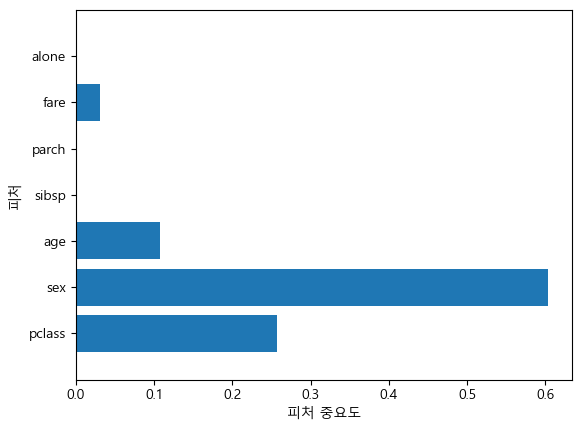

In [32]:
# 시각화
import numpy as np
import matplotlib.pyplot as plt

print("피처 중요도:", model.feature_importances_) # feature_importances_ 학습을 할 때 어떤 피쳐가 중요도를 미쳤는지 확인해준다.

plt.rcParams["font.family"] = 'Malgun Gothic'
n_features = X_train.shape[1]
plt.barh(np.arange(n_features), model.feature_importances_, align="center") # barh : 수평 막대
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("피처 중요도")
plt.ylabel("피처")
plt.ylim(-1, n_features)

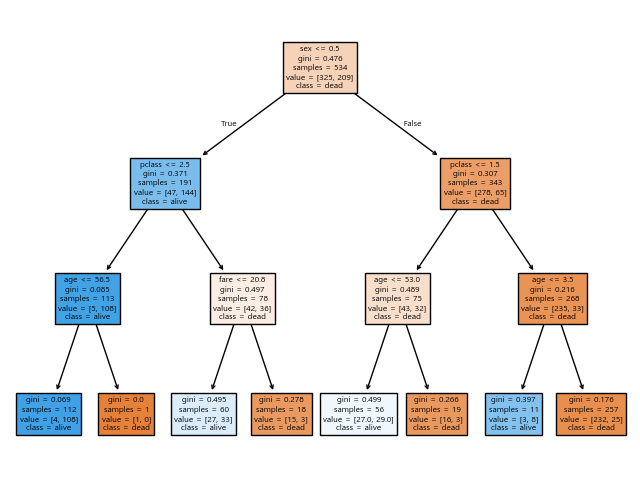

In [33]:
from sklearn.tree import plot_tree

label_val = {0: 'dead', 1:'alive'} # 분류

plt.figure(figsize=(8,6))
plot_tree(model.fit(X_train, y_train), feature_names = X_train.columns, class_names = label_val, filled = True)

# filled = True 색상을 채울지 말지 결정하는 것

plt.show()

# plot를 통해서 어떻게 분류가 되는지를 확인 할 수 있는 것

In [34]:
# 정확도를 높이는 방법은 하이퍼파라매터를 조정하는 작업이 있다
# 지금부터 그리드 서치를 사용해서 최적의 파라매터를 찾아라

In [35]:
# max_depth, criterion, splitter, min_samples_split, min_samples_leaf, max_leaf_nodes

In [36]:
from sklearn.model_selection import GridSearchCV

dt_model = DecisionTreeClassifier(random_state=42) # 기본 결정 트리 분류 객체를 만듦
parameters = {
    'criterion': ['gini', 'entropy'],          # 품질 측정 기준 엔트로피, 지니
    'splitter': ['best', 'random'],            # 노드 분할 전략
    'max_depth': [3, 5, 7, 10],                # 트리의 최대 깊이
    'min_samples_split': [2, 5, 10],           # 노드 분할을 위한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4],             # 리프 노드가 갖춰야 할 최소 샘플 수
    'max_leaf_nodes': [None, 10, 20, 30]       # 최대 리프 노드 개수
}

grid_dt = GridSearchCV(estimator=dt_model,     # 검증할 모델 지정         
                       param_grid=parameters,  # 위에서 지정한 파라매터 후보 딕셔너리를 함수에 전달
                       cv=5,                   # 교차 검증 분할 수
                       n_jobs=-1,              # 모든 코어 사용 (속도 향상)
                       verbose=1,              # 학습 과정을 로그메시지로 출력
                       refit=True)             # 최적의 파라매터를 찾은 후 전체 학습 데이터로 해당 모델을 다시 학습시켜 저장함

grid_dt.fit(X_train, y_train)                  # 모든 조합에 대한 교차 검증 및 학습 [fit()]


Fitting 5 folds for each of 576 candidates, totalling 2880 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [37]:
print(f"최적 파라미터: {grid_dt.best_params_}")  # 검증 결과 점수가 가장 높았던 파라미터 조합을 알려줌
print(f"최고 정확도: {grid_dt.best_score_:.4f}") # 최적 조합일 때의 평균 검증 정확도

최적 파라미터: {'criterion': 'gini', 'max_depth': 7, 'max_leaf_nodes': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'random'}
최고 정확도: 0.8278


# GridserchCV에 대한 공부 및 정리



### criterion : 분할의 품질을 측정하는 기준
- 결정 트리는 데이터를 나눌 때 순도 높게 나타내는 것이 중요한데 이때 사용하는 공식이 criteriion 이다.
- 그렇게 순도 높게 나타내는 방법으로 [지니, 엔트로피] 방법이 대표적으로 있다.

### splitter : 노드를 나누는 전략
-

In [38]:
# 현재까지 분류모델에 대한 설명이었고 이제 회귀모델에 대한 설명 및 공부를 해보자!!

In [39]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import warnings
warnings.filterwarnings('ignore')

In [40]:
df = pd.read_csv("boston_house.csv")
df.head(2)

,AGE,B,RM,CRIM,DIS,INDUS,LSTAT,NOX,PTRATIO,RAD,ZN,TAX,CHAS,Target
0,65.2,396.9,6.575,0.00632,4.0900,2.31,4.98,0.538,15.3,1,18.0,296,0,24.0
1,78.9,396.9,6.421,0.02731,4.9671,7.07,9.14,0.469,17.8,2,0.0,242,0,21.6


In [41]:
X = df.drop('Target', axis=1)
y = df['Target']

In [42]:
# 리프노드의 있는 값들의 평균값을 반환하는 회귀모델
# 이게 회귀모델이다. 마지막 노드에 대한 평균을 예측값으로 하는 회귀모델

# 다른것과 달라진 점은 모델명이 달라지고 MSE의 사용법이 조금 차이가 있을뿐 다른 차이는 크게 없다

reg = DecisionTreeRegressor(        
    criterion = 'squared_error', # 표준오차 MSE
    splitter='best',
    max_depth=4,
    min_samples_leaf=10,
    random_state=100).fit(X,y)

In [43]:
reg.predict(X)[:3]

array([24.39262295, 24.39262295, 37.19      ])

In [44]:
for i, col in enumerate(X.columns):
    print(f'{col} 중요도 : {reg.feature_importances_[i]}')

AGE 중요도 : 0.0
B 중요도 : 0.0
RM 중요도 : 0.6378647889973507
CRIM 중요도 : 0.03237114695675077
DIS 중요도 : 0.0019003403533124998
INDUS 중요도 : 0.0
LSTAT 중요도 : 0.2895167702659851
NOX 중요도 : 0.016289232640106757
PTRATIO 중요도 : 0.008088463872640467
RAD 중요도 : 0.0
ZN 중요도 : 0.013969256913853772
TAX 중요도 : 0.0
CHAS 중요도 : 0.0


In [45]:
print(reg.get_params())  # GET_PARAMS() 로 파라매터를 가져옴

{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 4, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 100, 'splitter': 'best'}


In [46]:
print('정확도 : ',reg.score(X,y))

정확도 :  0.8221210054368892


In [47]:
# 다시 시각화를 해보자

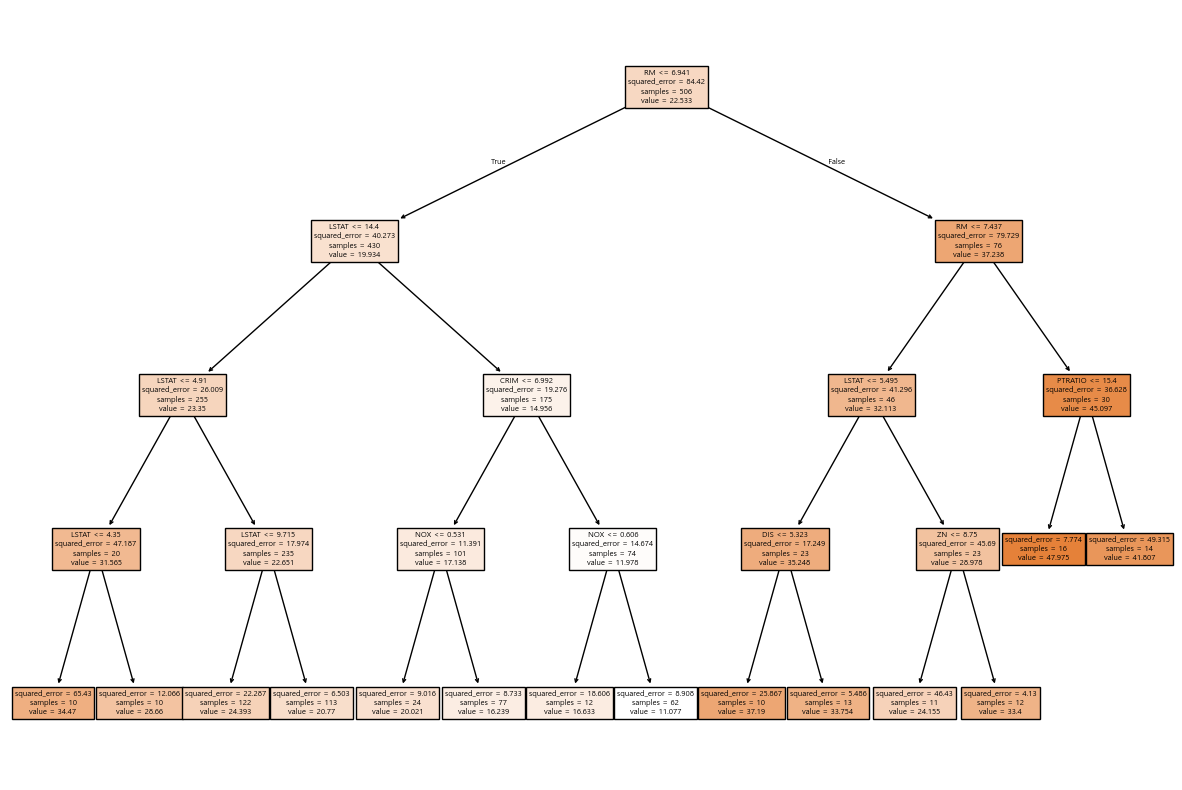

In [48]:
fig = plt.figure(figsize=(15,10))
plot_tree(reg, feature_names=X.columns, filled=True)
plt.show()

In [49]:
###

In [50]:
###

#  서울 지역 분류 실습 (2026-05-01)

In [51]:
import pandas as pd
import numpy as np

컬럼 주석
- district: 행정구역 (서초구, 송파구, 용산구 등, 서울의 단위 지역 분류입니다)
- dong: 구(district)보다 작은 행정구역 (대치동, 도곡동, 암사동 등, 서울의 소단위 분류입니다)
- longitude: 경도
- latitude: 위도
- label: 한강 기준으로 동,서,남,북으로 구분한 지역 명칭

In [52]:
# 데이터 불러오기 1
district_dict_list = [
            {'district': 'Gangseo-gu', 'latitude': 37.551000, 'longitude': 126.849500, 'label':'Gangseo'},
            {'district': 'Yangcheon-gu', 'latitude': 37.52424, 'longitude': 126.855396, 'label':'Gangseo'},
            {'district': 'Guro-gu', 'latitude': 37.4954, 'longitude': 126.8874, 'label':'Gangseo'},
            {'district': 'Geumcheon-gu', 'latitude': 37.4519, 'longitude': 126.9020, 'label':'Gangseo'},
            {'district': 'Mapo-gu', 'latitude': 37.560229, 'longitude': 126.908728, 'label':'Gangseo'},
            
            {'district': 'Gwanak-gu', 'latitude': 37.487517, 'longitude': 126.915065, 'label':'Gangnam'},
            {'district': 'Dongjak-gu', 'latitude': 37.5124, 'longitude': 126.9393, 'label':'Gangnam'},
            {'district': 'Seocho-gu', 'latitude': 37.4837, 'longitude': 127.0324, 'label':'Gangnam'},
            {'district': 'Gangnam-gu', 'latitude': 37.5172, 'longitude': 127.0473, 'label':'Gangnam'},
            {'district': 'Songpa-gu', 'latitude': 37.503510, 'longitude': 127.117898, 'label':'Gangnam'},
   
            {'district': 'Yongsan-gu', 'latitude': 37.532561, 'longitude': 127.008605, 'label':'Gangbuk'},
            {'district': 'Jongro-gu', 'latitude': 37.5730, 'longitude': 126.9794, 'label':'Gangbuk'},
            {'district': 'Seongbuk-gu', 'latitude': 37.603979, 'longitude': 127.056344, 'label':'Gangbuk'},
            {'district': 'Nowon-gu', 'latitude': 37.6542, 'longitude': 127.0568, 'label':'Gangbuk'},
            {'district': 'Dobong-gu', 'latitude': 37.6688, 'longitude': 127.0471, 'label':'Gangbuk'},
     
            {'district': 'Seongdong-gu', 'latitude': 37.557340, 'longitude': 127.041667, 'label':'Gangdong'},
            {'district': 'Dongdaemun-gu', 'latitude': 37.575759, 'longitude': 127.025288, 'label':'Gangdong'},
            {'district': 'Gwangjin-gu', 'latitude': 37.557562, 'longitude': 127.083467, 'label':'Gangdong'},
            {'district': 'Gangdong-gu', 'latitude': 37.554194, 'longitude': 127.151405, 'label':'Gangdong'},
            {'district': 'Jungrang-gu', 'latitude': 37.593684, 'longitude': 127.090384, 'label':'Gangdong'}
         ]

train_df = pd.DataFrame(district_dict_list)
train_df = train_df[['district', 'longitude', 'latitude', 'label']]

In [53]:
# 데이터 확인
train_df

,district,longitude,latitude,label
0,Gangseo-gu,126.849500,37.551000,Gangseo
1,Yangcheon-gu,126.855396,37.524240,Gangseo
2,Guro-gu,126.887400,37.495400,Gangseo
3,Geumcheon-gu,126.902000,37.451900,Gangseo
4,Mapo-gu,126.908728,37.560229,Gangseo
5,Gwanak-gu,126.915065,37.487517,Gangnam
6,Dongjak-gu,126.939300,37.512400,Gangnam
7,Seocho-gu,127.032400,37.483700,Gangnam
8,Gangnam-gu,127.047300,37.517200,Gangnam
9,Songpa-gu,127.117898,37.503510,Gangnam


In [54]:
# 데이터 불러오기 2
dong_dict_list = [
            {'dong': 'Gaebong-dong', 'latitude': 37.489853, 'longitude': 126.854547, 'label':'Gangseo'},
            {'dong': 'Gochuk-dong', 'latitude': 37.501394, 'longitude': 126.859245, 'label':'Gangseo'},
            {'dong': 'Hwagok-dong', 'latitude': 37.537759, 'longitude': 126.847951, 'label':'Gangseo'},
            {'dong': 'Banghwa-dong', 'latitude': 37.575817, 'longitude': 126.815719, 'label':'Gangseo'},
            {'dong': 'Sangam-dong', 'latitude': 37.577039, 'longitude': 126.891620, 'label':'Gangseo'},
            
            {'dong': 'Nonhyun-dong', 'latitude': 37.508838, 'longitude': 127.030720, 'label':'Gangnam'},
            {'dong': 'Daechi-dong', 'latitude': 37.501163, 'longitude': 127.057193, 'label':'Gangnam'},
            {'dong': 'Seocho-dong', 'latitude': 37.486401, 'longitude': 127.018281, 'label':'Gangnam'},
            {'dong': 'Bangbae-dong', 'latitude': 37.483279, 'longitude': 126.988194, 'label':'Gangnam'},
            {'dong': 'Dogok-dong', 'latitude': 37.492896, 'longitude': 127.043159, 'label':'Gangnam'},
    
            {'dong': 'Pyoungchang-dong', 'latitude': 37.612129, 'longitude': 126.975724, 'label':'Gangbuk'},
            {'dong': 'Sungbuk-dong', 'latitude': 37.597916, 'longitude': 126.998067, 'label':'Gangbuk'},
            {'dong': 'Ssangmoon-dong', 'latitude': 37.648094, 'longitude': 127.030421, 'label':'Gangbuk'},
            {'dong': 'Ui-dong', 'latitude': 37.648446, 'longitude': 127.011396, 'label':'Gangbuk'},
            {'dong': 'Samcheong-dong', 'latitude': 37.591109, 'longitude': 126.980488, 'label':'Gangbuk'},
    
            {'dong': 'Hwayang-dong', 'latitude': 37.544234, 'longitude': 127.071648, 'label':'Gangdong'},
            {'dong': 'Gui-dong', 'latitude': 37.543757, 'longitude': 127.086803, 'label':'Gangdong'},
            {'dong': 'Neung-dong', 'latitude': 37.553102, 'longitude': 127.080248, 'label':'Gangdong'},
            {'dong': 'Amsa-dong', 'latitude': 37.552370, 'longitude': 127.127124, 'label':'Gangdong'},
            {'dong': 'Chunho-dong', 'latitude': 37.547436, 'longitude': 127.137382, 'label':'Gangdong'}
         ]

test_df = pd.DataFrame(dong_dict_list)
test_df = test_df[['dong', 'longitude', 'latitude', 'label']]

In [55]:
# 데이터 확인
test_df

,dong,longitude,latitude,label
0,Gaebong-dong,126.854547,37.489853,Gangseo
1,Gochuk-dong,126.859245,37.501394,Gangseo
2,Hwagok-dong,126.847951,37.537759,Gangseo
3,Banghwa-dong,126.815719,37.575817,Gangseo
4,Sangam-dong,126.891620,37.577039,Gangseo
5,Nonhyun-dong,127.030720,37.508838,Gangnam
6,Daechi-dong,127.057193,37.501163,Gangnam
7,Seocho-dong,127.018281,37.486401,Gangnam
8,Bangbae-dong,126.988194,37.483279,Gangnam
9,Dogok-dong,127.043159,37.492896,Gangnam


In [56]:
# 라벨의 벨류 개수 확인
train_df.label.value_counts()

label
Gangseo     5
Gangnam     5
Gangbuk     5
Gangdong    5
Name: count, dtype: int64

In [57]:
# 라벨의 벨류 개수 확인
test_df.label.value_counts()

label
Gangseo     5
Gangnam     5
Gangbuk     5
Gangdong    5
Name: count, dtype: int64

In [58]:
# 이어서 간단한 시각화 작업

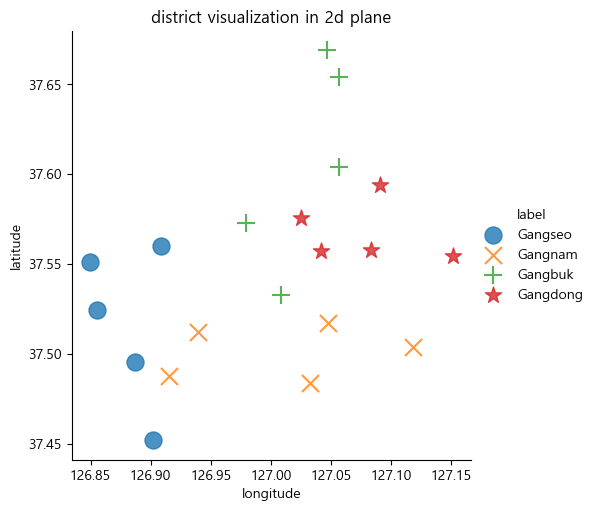

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# fit_reg=False : 회귀 직선 그릴지 여부, 
sns.lmplot(x='longitude', y='latitude', data=train_df, fit_reg=False, scatter_kws={"s": 150},
           markers=["o", "x", "+", "*"], hue="label")
plt.title('district visualization in 2d plane')
plt.show()

In [60]:
# 위도 경도 추출 테스트 데이터도 동일하게 사용

train_df.drop(['district'], axis=1, inplace = True)
test_df.drop(['dong'], axis=1, inplace = True)

X_train = train_df[['longitude', 'latitude']]
y_train = train_df[['label']]

X_test = test_df[['longitude', 'latitude']]
y_test = test_df[['label']]

In [61]:
from sklearn import tree
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [62]:
# 차트를 그리는 작업 
# 

def display_decision_surface(clf,X, y):
    x_min = X.longitude.min() - 0.01
    x_max = X.longitude.max() + 0.01
    y_min = X.latitude.min() - 0.01
    y_max = X.latitude.max() + 0.01

    n_classes = len(le.classes_)
    plot_colors = "rywb"
    plot_step = 0.001

    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)

    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i) 
        plt.scatter(X.loc[idx].longitude, 
                    X.loc[idx].latitude, 
                    c=color, 
                    label=le.classes_[i],
                    cmap=plt.cm.RdYlBu, edgecolor='black', s=200)

    plt.title("Decision surface of a decision tree",fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=14)
    plt.xlabel('longitude',fontsize=16)
    plt.ylabel('latitude',fontsize=16)
    plt.rcParams["figure.figsize"] = [7,5]
    plt.rcParams["font.size"] = 14
    plt.rcParams["xtick.labelsize"] = 14
    plt.rcParams["ytick.labelsize"] = 14
    plt.show()


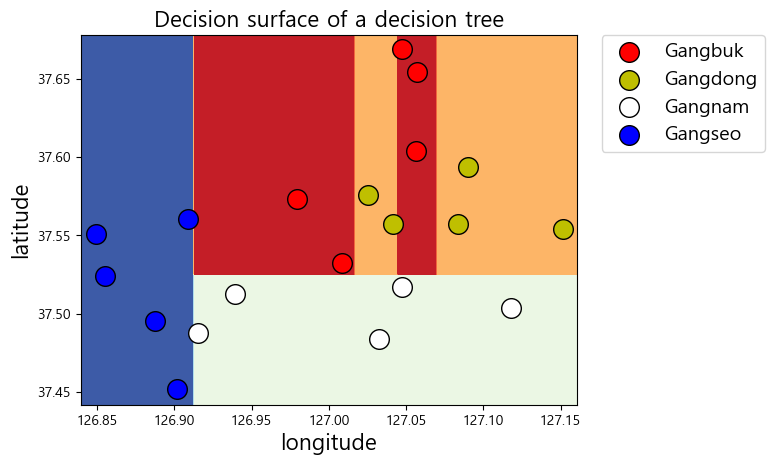

In [63]:
le = preprocessing.LabelEncoder()
y_encoded = le.fit_transform(y_train)

clf = tree.DecisionTreeClassifier(random_state=35).fit(X_train, y_encoded) # max_depth는 따로 설정하게 없어서 최대치가 된다.
display_decision_surface(clf,X_train, y_encoded)


## 학습데이터에 최적화 되어있어서 다른 데이터를 집어 넣었을 때, 현재 데이터가 아닌 다른 데이터를 최적화로 분류하기에는 어렵다
## 반면에 아래의 경우에는 현재 학습데이터에 최저고하 되어 있지 않지만 새로운 테스트 데이터를 집어넣을 때, 세분화 되어있지 않기 때문에 다른 데이터를 집어넣어도
#  일반화 측면에서 잘 분류한다 즉, 정확도가 더 높고 성능을 높일 수 있다.

# 즉, 학습 데이터의 성능을 높이는 것이 우린의 목표가 아니기에 가지치기를 잘 해서 일반화가 잘 된 모델을 만들 수 있다.

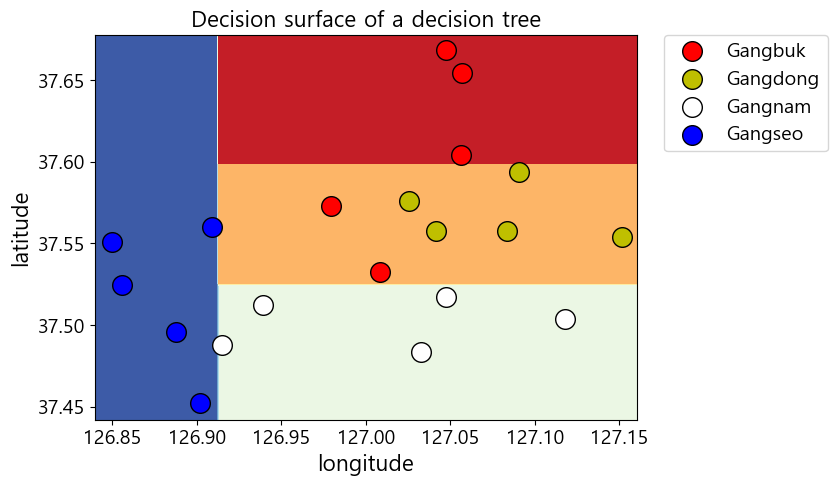

In [64]:
clf = tree.DecisionTreeClassifier(max_depth=3,         # 
                                 min_samples_split=3,  # 분리 할 때 최소한의 노드가 몇 개가 필요한가에 대한 코드
                                 min_samples_leaf=3,   # 클 수록 가지치기 효과가 있다. 한 노드가 가지고 있어야할 최소 샘플 개수
                                 random_state=5).fit(X_train, y_encoded.ravel())
display_decision_surface(clf,X_train, y_encoded)

# project 6

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('양치전처리.csv')
df.head(10)

# columns : 18 , row : 11898
# target : NO_CPI_34 [치주질환 여부]

,NO_CPI_34,age,sex,BS3_1,DE1_dg,BD1_11,OR1_2,DF2_pr,BP1,Total_slp_wk,Total_slp_wd,BM1,BM2_1,BM2_2,BM2_3,BM2_4,BM2_5,HE_BMI
0,0.0,80.0,2.0,4.0,0.0,4.0,0.0,0.0,4.0,600.0,600.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0
1,0.0,59.0,2.0,4.0,0.0,2.0,1.0,0.0,3.0,420.0,360.0,4.0,1.0,1.0,1.0,0.0,0.0,2.0
2,0.0,68.0,1.0,1.0,0.0,6.0,0.0,0.0,3.0,510.0,510.0,3.0,0.0,0.0,1.0,0.0,0.0,2.0
3,0.0,64.0,2.0,4.0,1.0,0.0,1.0,0.0,3.0,240.0,240.0,2.0,1.0,1.0,0.0,0.0,0.0,3.0
4,0.0,77.0,1.0,3.0,1.0,2.0,0.0,0.0,4.0,480.0,480.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0
5,1.0,68.0,2.0,4.0,0.0,0.0,0.0,0.0,4.0,360.0,300.0,2.0,0.0,0.0,1.0,0.0,0.0,3.0
6,1.0,66.0,1.0,3.0,0.0,2.0,0.0,0.0,3.0,480.0,480.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0
7,0.0,60.0,2.0,4.0,0.0,2.0,1.0,0.0,3.0,600.0,660.0,3.0,1.0,0.0,0.0,0.0,0.0,3.0
8,1.0,47.0,1.0,4.0,0.0,5.0,1.0,0.0,3.0,300.0,420.0,2.0,1.0,0.0,0.0,0.0,0.0,2.0
9,0.0,45.0,2.0,4.0,0.0,3.0,0.0,0.0,2.0,390.0,540.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0


연령 : age

성별 : sex 
(1: 남자, 2:여자)

흡연 여부 : BS3_1
(1: 매일피움, 2: 가끔, 3: 과거에는 피웠으나, 현재 피우지 않음, 0: 비해당)

음주 빈도 : BD1_11 
(1: 최근 1년간 전혀 마시지 않았다, 2: 월1회미만, 3: 월1회정도, 4: 월2~4회, 5: 주2~3회정도, 6: 주4회이상, 0: 비해당)

칫솔질 여부 : BMI_1 ~ 8 
(0: 아니오, 1: 예, 0: 비해당(칫솔질 안했음))

구강용품 : BM2_1 ~ 5 
(0:아니오, 1: 예, 0: 비해당(12세미만))

구강검진(정기검진) : OR1_2
(0: 아니오, 1: 예)

당뇨여부 : DE1_dg 
(0: 없음, 1: 있음)

치주질환여부 : NO_CPI_34 
(0: 아니오, 1: 예)

우울증 여부 : DF2_pr
(0: 없음, 1: 있음)

평소 스트레스 인지 정도 : BP1 
(1. 대단히 많이 느낀다, 2. 많이 느끼는 편이다, 3. 조금 느끼는 편이다, 4. 거의 느끼지 않는다.)

비만 여부 : HE_BMI
(1. 저체중, 2. 정상, 3. 비만)

주중 하루 평균 수면시간 : Total_slp_wk 
(()분, 8888. 비해당(소아), 9999. 모름, 무응답) ** 8888, 9999값 삭제

주말 하루 평균 수면시간 : Total_slp_wd
(()분, 8888. 비해당(소아), 9999. 모름, 무응답) ** 8888, 9999값 삭제


In [103]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# 1. 데이터 불러오기
df = pd.read_csv('양치전처리.csv')

# 2. 수면 시간 특수값(8888, 9999) 제거
# 이 값들을 NaN으로 바꾼 후 행 전체를 삭제하여 데이터의 신뢰도를 높입니다.
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

# 3. 모든 문자열(Object) 데이터를 숫자로 변환 (ValueError 방지)
# HE_BMI 컬럼에 '비만', '정상' 등이 있어도 이 루프를 통해 모두 숫자로 바뀝니다.
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

# 4. 피처(X)와 타겟(y) 분리
# target : NO_CPI_34
X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 5. 데이터 분할 (학습용 75%, 테스트용 25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 6. 최적의 파라미터(max_depth, random_state) 탐색
# 정확도를 높이기 위해 이중 반복문을 사용합니다.
best_score = 0
best_depth = 0
best_rs = 0

print("최적의 모델 설정을 찾는 중입니다...")

for depth in range(3, 11):      # 나무 깊이 3~10 탐색
    for rs in range(0, 10100):    # 난수 고정값 0~100 탐색
        model = DecisionTreeClassifier(max_depth=depth, random_state=rs)
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
        
        if score > best_score:
            best_score = score
            best_depth = depth
            best_rs = rs

# 7. 결과 출력 및 최종 모델 확인
print("-" * 50)
print(f"최적 파라미터: max_depth={best_depth}, random_state={best_rs}")
print(f"최고 정확도: {best_score:.4f}")
print("-" * 50)

# 최적화된 설정으로 최종 모델 학습
final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=best_rs)
final_model.fit(X_train, y_train)

# 상세 성능 보고서 (정확도 외에 정밀도, 재현율 확인)
y_pred = final_model.predict(X_test)
print("\n[상세 분석 보고서]")
print(classification_report(y_test, y_pred))

최적의 모델 설정을 찾는 중입니다...
--------------------------------------------------
최적 파라미터: max_depth=5, random_state=0
최고 정확도: 0.7172
--------------------------------------------------

[상세 분석 보고서]
              precision    recall  f1-score   support

         0.0       0.77      0.84      0.80      2077
         1.0       0.55      0.43      0.49       929

    accuracy                           0.72      3006
   macro avg       0.66      0.64      0.65      3006
weighted avg       0.70      0.72      0.71      3006



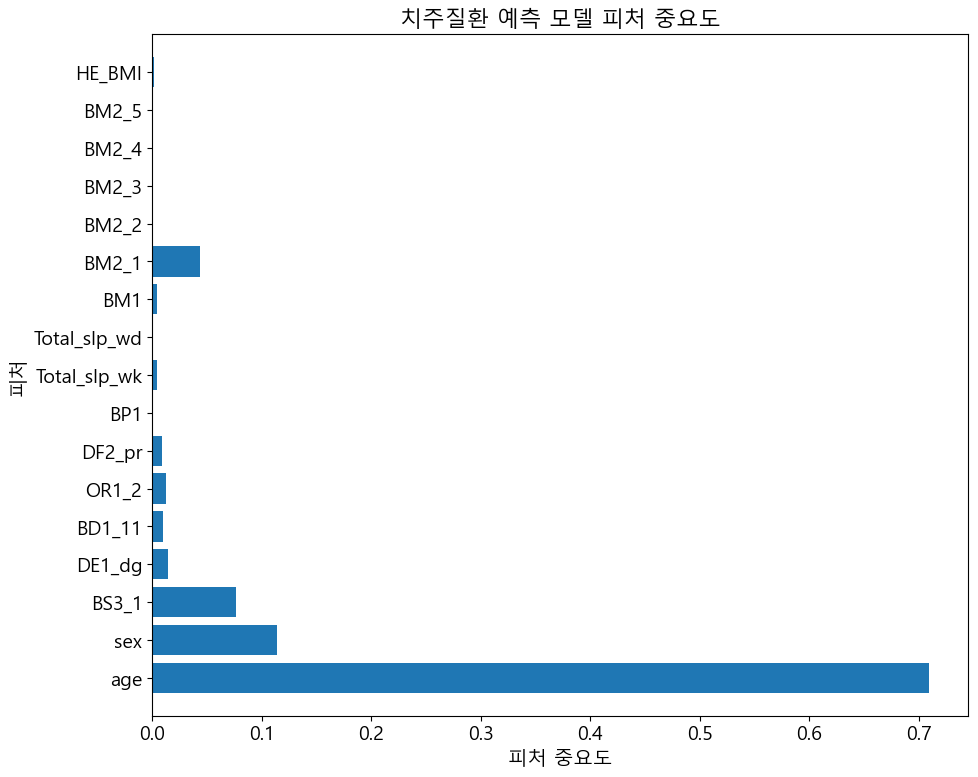

In [104]:
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정 (그래프에서 한글이 깨지지 않도록 하기 위함)
# 사용자님의 PC 환경에 따라 설정이 다를 수 있습니다. (예: Mac은 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic' 

# 그래기 사이즈 설정
plt.figure(figsize=(10, 8))

# 1. 학습에 사용된 피처(X)의 개수 파악
n_features = X_train.shape[1]

# 2. 피처 중요도 값 가져오기
# final_model은 최적의 파라미터로 학습된 최종 모델 변수명입니다.
importances = final_model.feature_importances_

# 3. 수평 막대 그래프 그리기 (barh)
# y축 위치, x축 값(중요도), 중앙 정렬
plt.barh(np.arange(n_features), importances, align='center')

# 4. y축 눈금 설정 (피처 이름 출력)
plt.yticks(np.arange(n_features), X_train.columns)

# 5. 그래프 제목 및 축 이름 설정
plt.title('치주질환 예측 모델 피처 중요도', fontsize=16)
plt.xlabel('피처 중요도', fontsize=14)
plt.ylabel('피처', fontsize=14)

# 6. y축 범위 설정 및 그래프 출력
plt.ylim(-1, n_features)
plt.tight_layout() # 그래프 요소들이 겹치지 않게 조절
plt.show()

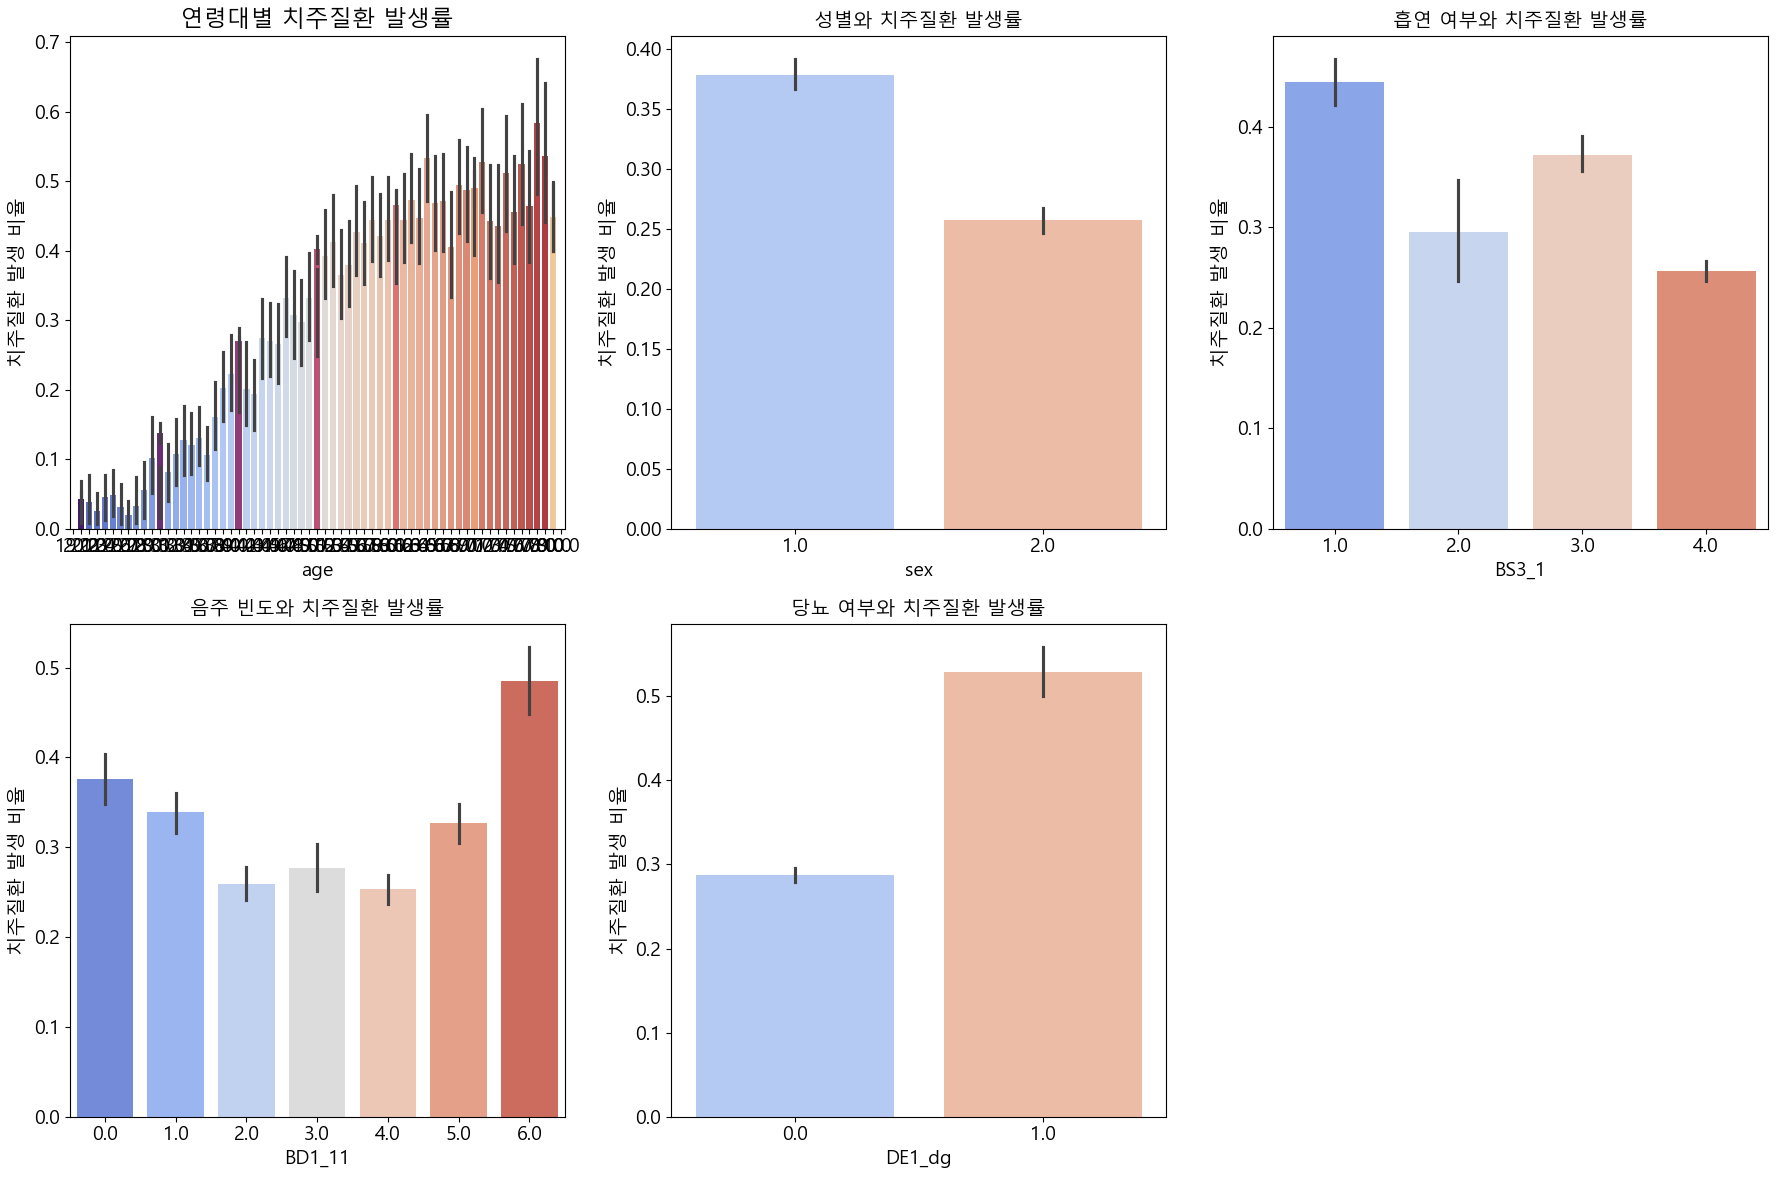

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드 (양치전처리.csv 사용)
df = pd.read_csv('양치전처리.csv')

# 2. 분석할 주요 컬럼 리스트
cols = ['age', 'sex', 'BS3_1', 'BD1_11', 'DE1_dg']
col_names = ['연령', '성별', '흡연 여부', '음주 빈도', '당뇨 여부']

# 3. 서브플롯 생성 (2행 3열)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    # 각 변수별로 치주질환(NO_CPI_34)의 평균(발생률)을 계산하여 그래프 작성
    sns.barplot(x=col, y='NO_CPI_34', data=df, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col_names[i]}와 치주질환 발생률', fontsize=14)
    axes[i].set_ylabel('치주질환 발생 비율')
    
    # 연령(age)의 경우 데이터가 많으므로 10대 단위로 묶어서 보면 더 정확합니다.
    if col == 'age':
        df['age_group'] = (df['age'] // 10) * 10
        sns.barplot(x='age_group', y='NO_CPI_34', data=df, ax=axes[i], palette='magma')
        axes[i].set_title('연령대별 치주질환 발생률')

# 나머지 빈 그래프 삭제
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

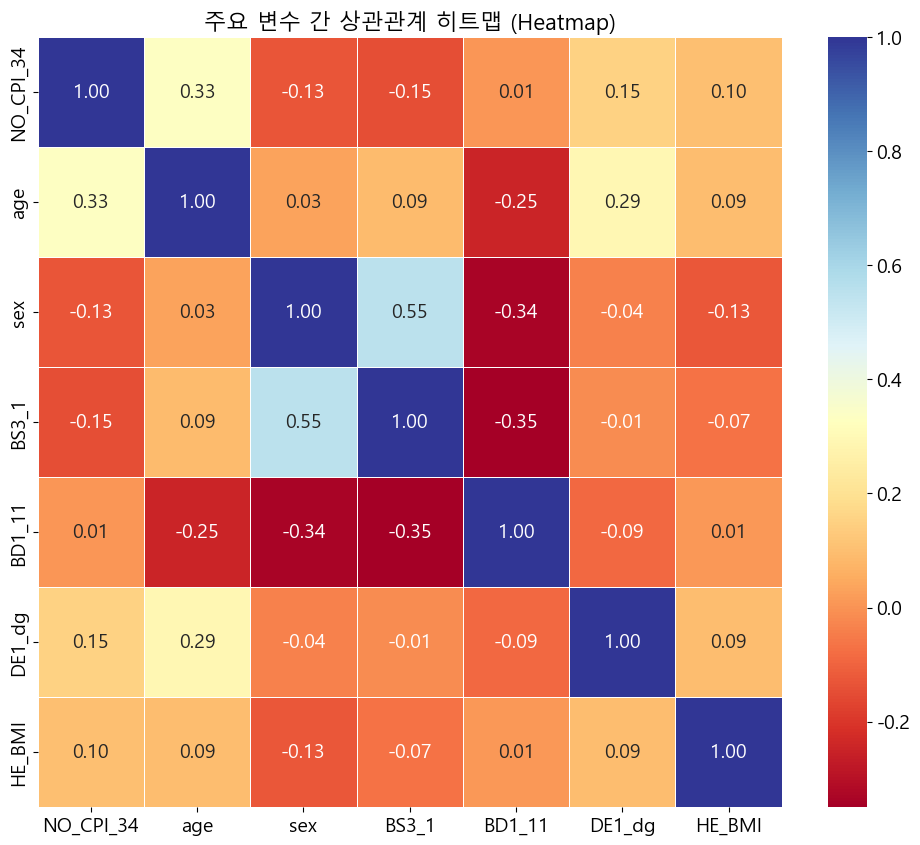

In [106]:
plt.figure(figsize=(12, 10))

# 상관계수 계산
corr_matrix = df[['NO_CPI_34', 'age', 'sex', 'BS3_1', 'BD1_11', 'DE1_dg', 'HE_BMI']].corr()

# 히트맵 그리기
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu', fmt=".2f", linewidths=0.5)
plt.title('주요 변수 간 상관관계 히트맵 (Heatmap)', fontsize=16)
plt.show()

In [107]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# 1. 데이터 불러오기
df = pd.read_csv('양치전처리.csv')

# 2. 수면 시간 특수값 제거 및 결측치 처리
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

# 3. 모든 문자열 데이터를 숫자로 변환 (LabelEncoding)
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

# 4. 피처(X)와 타겟(y) 분리
X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 5. 데이터 분할 (7.5 : 2.5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 6. GridSearchCV 설정
# 탐색할 파라미터 조합을 정의합니다.
parameters = {
    'max_depth': [3, 5, 7, 10],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 기본 모델 객체 생성 (random_state는 고정하여 실험의 재현성을 확보합니다)
dt_model = DecisionTreeClassifier(random_state=42)

# GridSearchCV 객체 생성
grid_dt = GridSearchCV(
    estimator=dt_model, 
    param_grid=parameters, 
    cv=5,           # 5-폴드 교차 검증
    n_jobs=-1,      # 모든 CPU 코어 사용
    verbose=1,      # 진행 과정 로그 출력
    refit=True      # 최적 파라미터로 최종 학습 진행
)

print("GridSearchCV를 통한 최적 파라미터 탐색 시작...")
grid_dt.fit(X_train, y_train)

# 7. 결과 출력 및 상세 보고서
print("-" * 50)
print(f"최적 파라미터: {grid_dt.best_params_}")
print(f"최고 교차 검증 정확도: {grid_dt.best_score_:.4f}")
print("-" * 50)

# 최적의 모델(best_estimator_)로 테스트 데이터 예측
best_model = grid_dt.best_estimator_
y_pred = best_model.predict(X_test)

print("\n[상세 분석 보고서 - Test Data]")
print(classification_report(y_test, y_pred))

GridSearchCV를 통한 최적 파라미터 탐색 시작...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
--------------------------------------------------
최적 파라미터: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
최고 교차 검증 정확도: 0.7065
--------------------------------------------------

[상세 분석 보고서 - Test Data]
              precision    recall  f1-score   support

         0.0       0.72      0.96      0.82      2077
         1.0       0.65      0.16      0.25       929

    accuracy                           0.71      3006
   macro avg       0.68      0.56      0.54      3006
weighted avg       0.70      0.71      0.65      3006



In [108]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 불러오기 및 전처리 (이전과 동일)
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. GridSearchCV 설정 변경
# class_weight='balanced'를 추가하여 불균형 데이터를 처리합니다.
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

parameters = {
    'max_depth': [3, 5, 7, 9, 11],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# scoring을 'f1'으로 설정하여 F1-score가 가장 높은 조합을 찾습니다.
grid_dt = GridSearchCV(
    estimator=dt_model, 
    param_grid=parameters, 
    cv=5, 
    n_jobs=-1, 
    scoring='f1',  # 핵심: F1 점수 최적화
    verbose=1,
    refit=True
)

print("F1-score 최적화 탐색 시작...")
grid_dt.fit(X_train, y_train)

# 3. 결과 확인
print("-" * 50)
print(f"최적 파라미터: {grid_dt.best_params_}")
print(f"최고 F1-score (CV): {grid_dt.best_score_:.4f}")
print("-" * 50)

best_model = grid_dt.best_estimator_
y_pred = best_model.predict(X_test)

print("\n[F1-score 최적화 후 상세 보고서]")
print(classification_report(y_test, y_pred))

F1-score 최적화 탐색 시작...
Fitting 5 folds for each of 120 candidates, totalling 600 fits
--------------------------------------------------
최적 파라미터: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 20}
최고 F1-score (CV): 0.5787
--------------------------------------------------

[F1-score 최적화 후 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.86      0.58      0.70      2077
         1.0       0.46      0.79      0.58       929

    accuracy                           0.65      3006
   macro avg       0.66      0.69      0.64      3006
weighted avg       0.74      0.65      0.66      3006



In [109]:
#랜덤 포레스트

In [110]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. 랜덤 포레스트 및 GridSearchCV 설정
# n_estimators: 사용할 나무의 개수 (많을수록 안정적이나 속도가 느려짐)
# class_weight='balanced_subsample': 불균형 데이터셋에서 소수 클래스(환자)에 더 집중하게 함
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced_subsample')

parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# F1-score를 기준으로 최적의 파라미터를 탐색합니다.
grid_rf = GridSearchCV(
    estimator=rf_model, 
    param_grid=parameters, 
    cv=3,           # 시간 단축을 위해 3-fold 사용 (필요시 5로 변경 가능)
    n_jobs=-1, 
    scoring='f1',   
    verbose=1,
    refit=True
)

print("랜덤 포레스트 F1-score 최적화 탐색 시작...")
grid_rf.fit(X_train, y_train)

# 3. 결과 확인
print("-" * 50)
print(f"최적 파라미터: {grid_rf.best_params_}")
print(f"최고 F1-score (CV): {grid_rf.best_score_:.4f}")
print("-" * 50)

best_rf = grid_rf.best_estimator_
y_pred = best_rf.predict(X_test)

print("\n[랜덤 포레스트 최종 상세 보고서]")
print(classification_report(y_test, y_pred))

랜덤 포레스트 F1-score 최적화 탐색 시작...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
--------------------------------------------------
최적 파라미터: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
최고 F1-score (CV): 0.5827
--------------------------------------------------

[랜덤 포레스트 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.87      0.59      0.70      2077
         1.0       0.47      0.81      0.59       929

    accuracy                           0.65      3006
   macro avg       0.67      0.70      0.65      3006
weighted avg       0.75      0.65      0.67      3006



In [111]:
# xgboost

In [112]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. 불균형 데이터 처리를 위한 가중치 계산 (환자 비율 고려)
# 정상(0) 개수 / 환자(1) 개수 비율을 구하여 소수 클래스에 힘을 실어줍니다.
spw = float(np.sum(y==0) / np.sum(y==1))

# 3. XGBoost 하이퍼파라미터 설정
xgb_model = XGBClassifier(
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss',
    scale_pos_weight=spw  # 핵심: F1-score를 높이는 가중치 파라미터
)

parameters = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8] # 과적합 방지를 위해 데이터의 일부만 사용하여 학습
}

# 4. GridSearchCV 실행 (F1-score 기준)
grid_xgb = GridSearchCV(
    estimator=xgb_model, 
    param_grid=parameters, 
    cv=3, 
    n_jobs=-1, 
    scoring='f1',   
    verbose=1,
    refit=True
)

print("XGBoost F1-score 극한 최적화 시작...")
grid_xgb.fit(X_train, y_train)

# 5. 결과 확인
print("-" * 50)
print(f"최적 파라미터: {grid_xgb.best_params_}")
print(f"최고 F1-score (CV): {grid_xgb.best_score_:.4f}")
print("-" * 50)

best_xgb = grid_xgb.best_estimator_
y_pred = best_xgb.predict(X_test)

print("\n[XGBoost 최종 상세 보고서]")
print(classification_report(y_test, y_pred))

XGBoost F1-score 극한 최적화 시작...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
--------------------------------------------------
최적 파라미터: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.7}
최고 F1-score (CV): 0.5819
--------------------------------------------------

[XGBoost 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.88      0.58      0.70      2077
         1.0       0.46      0.82      0.59       929

    accuracy                           0.65      3006
   macro avg       0.67      0.70      0.64      3006
weighted avg       0.75      0.65      0.66      3006



In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. SVM 필수 단계: 데이터 표준화 (Feature Scaling)
# SVM은 거리 기반 모델이므로 스케일링이 필수입니다.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. SVM 모델 설정
# class_weight='balanced'는 XGBoost의 scale_pos_weight와 유사한 역할을 합니다.
svm_model = SVC(random_state=42, class_weight='balanced')

# 5. 하이퍼파라미터 그리드 설정
# C: 규제 강도 (작을수록 마진이 넓어짐), gamma: 결정 경계의 유연성
parameters = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear'] # rbf가 일반적이지만 선형 관계도 확인
}

# 6. GridSearchCV 실행 (F1-score 기준)
grid_svm = GridSearchCV(
    estimator=svm_model, 
    param_grid=parameters, 
    cv=3, 
    n_jobs=-1, 
    scoring='f1',   
    verbose=1,
    refit=True
)

print("SVM F1-score 최적화 시작... (데이터 양에 따라 시간이 걸릴 수 있습니다)")
grid_svm.fit(X_train_scaled, y_train)

# 7. 결과 확인
print("-" * 50)
print(f"최적 파라미터: {grid_svm.best_params_}")
print(f"최고 F1-score (CV): {grid_svm.best_score_:.4f}")
print("-" * 50)

best_svm = grid_svm.best_estimator_
y_pred = best_svm.predict(X_test_scaled)

print("\n[SVM 최종 상세 보고서]")
print(classification_report(y_test, y_pred))

SVM F1-score 최적화 시작... (데이터 양에 따라 시간이 걸릴 수 있습니다)
Fitting 3 folds for each of 32 candidates, totalling 96 fits
--------------------------------------------------
최적 파라미터: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
최고 F1-score (CV): 0.5803
--------------------------------------------------

[SVM 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.86      0.62      0.72      2077
         1.0       0.47      0.77      0.59       929

    accuracy                           0.66      3006
   macro avg       0.67      0.69      0.65      3006
weighted avg       0.74      0.66      0.68      3006



In [2]:
# seed 값 조정 dt

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

# 1. 데이터 로드 및 기본 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. Random State 탐색 설정
best_f1 = 0
best_rs = -1
results = []

print("최적의 random_state 탐색 시작 (0 ~ 1000)...")

# 성능을 일정하게 비교하기 위해 하이퍼파라미터는 이전 GridSearchCV의 최적값으로 고정합니다.
# (이전 결과: max_depth=5, min_samples_leaf=5, min_samples_split=20 등)
for rs in range(0, 1001):
    # 데이터 분할 시에도 동일한 rs 적용
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=rs)
    
    # 모델 선언 (이전 최적 파라미터 적용 권장)
    dt_model = DecisionTreeClassifier(
        max_depth=5, 
        min_samples_leaf=5, 
        min_samples_split=20, 
        criterion='gini',
        class_weight='balanced',
        random_state=rs
    )
    
    dt_model.fit(X_train, y_train)
    y_pred = dt_model.predict(X_test)
    
    # F1-score 계산 (환자 클래스인 1에 대한 점수)
    current_f1 = f1_score(y_test, y_pred)
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_rs = rs
        
    # 100단위로 진행 상황 출력
    if rs % 100 == 0:
        print(f"Progress: {rs}/1000... Current Best F1: {best_f1:.4f} (at RS {best_rs})")

# 3. 최종 결과 출력
print("-" * 50)
print(f"최종 최적 random_state: {best_rs}")
print(f"최고 F1-score: {best_f1:.4f}")
print("-" * 50)

# 최적의 rs로 다시 학습하여 상세 보고서 출력
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=best_rs)
final_model = DecisionTreeClassifier(
    max_depth=5, 
    min_samples_leaf=5, 
    min_samples_split=20, 
    class_weight='balanced', 
    random_state=best_rs
)
final_model.fit(X_train, y_train)
print(classification_report(y_test, final_model.predict(X_test)))

최적의 random_state 탐색 시작 (0 ~ 1000)...
Progress: 0/1000... Current Best F1: 0.5664 (at RS 0)
Progress: 100/1000... Current Best F1: 0.6063 (at RS 83)
Progress: 200/1000... Current Best F1: 0.6063 (at RS 83)
Progress: 300/1000... Current Best F1: 0.6063 (at RS 83)
Progress: 400/1000... Current Best F1: 0.6097 (at RS 337)
Progress: 500/1000... Current Best F1: 0.6097 (at RS 337)
Progress: 600/1000... Current Best F1: 0.6097 (at RS 337)
Progress: 700/1000... Current Best F1: 0.6097 (at RS 337)
Progress: 800/1000... Current Best F1: 0.6097 (at RS 337)
Progress: 900/1000... Current Best F1: 0.6097 (at RS 337)
Progress: 1000/1000... Current Best F1: 0.6097 (at RS 337)
--------------------------------------------------
최종 최적 random_state: 337
최고 F1-score: 0.6097
--------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.86      0.58      0.69      2015
         1.0       0.49      0.81      0.61       991

    accuracy         

# 결정 트리 다시

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. 모델 설정 및 하이퍼파라미터 튜닝
# class_weight='balanced'는 유지하여 불균형을 해소합니다.
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# [개선 전략 적용]
# 1) 가지치기 강화: max_depth를 낮추고 min_samples_leaf를 높여 과적합 방지
# 2) 엔트로피 적용: criterion에 'entropy'를 우선적으로 탐색
parameters = {
    'max_depth': [3, 4, 5, 6],           # 깊이를 제한하여 일반화 성능 향상 (기존보다 낮춤)
    'criterion': ['entropy'],            # 더 균형 잡힌 분할을 위해 엔트로피 고정 사용
    'min_samples_split': [10, 20, 30],   # 노드 분할을 위한 최소 샘플 수 상향
    'min_samples_leaf': [5, 10, 15]      # 리프 노드의 최소 샘플 수를 늘려 "난사" 방지 (Precision 개선)
}

grid_dt = GridSearchCV(
    estimator=dt_model, 
    param_grid=parameters, 
    cv=5, 
    n_jobs=-1, 
    scoring='f1',  
    verbose=1,
    refit=True
)

print("가지치기 및 엔트로피 기반 F1-score 최적화 시작...")
grid_dt.fit(X_train, y_train)

# 3. 결과 확인
print("-" * 50)
print(f"최적 파라미터: {grid_dt.best_params_}")
print(f"최고 F1-score (CV): {grid_dt.best_score_:.4f}")
print("-" * 50)

best_model = grid_dt.best_estimator_
y_pred = best_model.predict(X_test)

print("\n[개선된 Decision Tree 상세 보고서]")
print(classification_report(y_test, y_pred))

가지치기 및 엔트로피 기반 F1-score 최적화 시작...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
--------------------------------------------------
최적 파라미터: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 10}
최고 F1-score (CV): 0.5770
--------------------------------------------------

[개선된 Decision Tree 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.86      0.61      0.71      2077
         1.0       0.47      0.78      0.59       929

    accuracy                           0.66      3006
   macro avg       0.66      0.69      0.65      3006
weighted avg       0.74      0.66      0.67      3006



In [5]:
# 보험용 연령, 성별 당뇨여부, 정기검진여부

선택된 4개 변수 기반 F1-score 최적화 시작...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
--------------------------------------------------
최적 파라미터: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 10}
최고 F1-score (CV): 0.5748
--------------------------------------------------

[선택 변수(연령, 성별, 당뇨, 검진) 기반 Decision Tree 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.89      0.52      0.66      2077
         1.0       0.44      0.86      0.59       929

    accuracy                           0.62      3006
   macro avg       0.67      0.69      0.62      3006
weighted avg       0.75      0.62      0.63      3006



C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_21064\1260750.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp, y=feature_imp.index, palette='viridis')
C:\Project\Project_source\AI01\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\Project_source\AI01\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\Project_source\AI01\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\Project_source\AI01\.venv\Lib

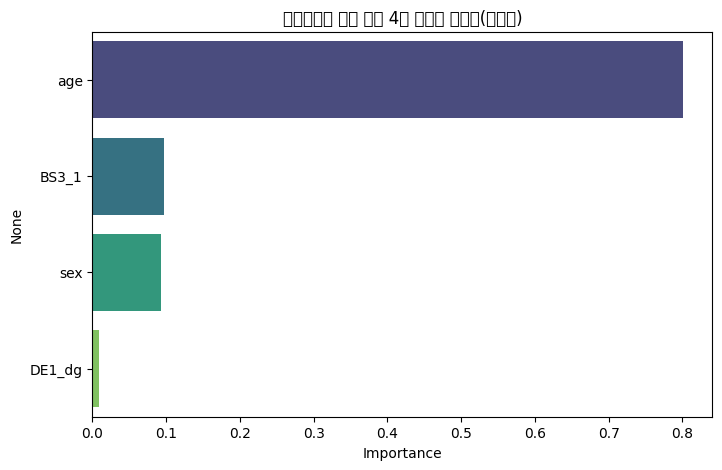

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')

# 사용자가 요청한 4가지 핵심 컬럼 + 타겟 컬럼 선택
# (데이터셋의 실제 영문명에 맞춰 age, sex, DE1_dg, BS3_1로 설정)
target_col = 'NO_CPI_34'
selected_features = ['age', 'sex', 'DE1_dg', 'BS3_1']
X = df[selected_features]
y = df[target_col]

# 결측치 처리 및 인코딩
# (수면 관련 데이터 처리는 선택된 변수에 포함되지 않으므로 생략하고 전체 결측 행 제거)
data_combined = pd.concat([X, y], axis=1).dropna().reset_index(drop=True)
X = data_combined[selected_features]
y = data_combined[target_col]

le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object': 
        X.loc[:, col] = le.fit_transform(X[col].astype(str))

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. 모델 설정 및 하이퍼파라미터 튜닝 (가지치기 및 엔트로피 적용)
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

parameters = {
    'max_depth': [3, 4, 5, 6],
    'criterion': ['entropy'],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15]
}

grid_dt = GridSearchCV(
    estimator=dt_model, 
    param_grid=parameters, 
    cv=5, 
    n_jobs=-1, 
    scoring='f1',  
    verbose=1,
    refit=True
)

print("선택된 4개 변수 기반 F1-score 최적화 시작...")
grid_dt.fit(X_train, y_train)

# 3. 결과 확인 및 상세 보고서 출력
print("-" * 50)
print(f"최적 파라미터: {grid_dt.best_params_}")
print(f"최고 F1-score (CV): {grid_dt.best_score_:.4f}")
print("-" * 50)

best_model = grid_dt.best_estimator_
y_pred = best_model.predict(X_test)

print("\n[선택 변수(연령, 성별, 당뇨, 검진) 기반 Decision Tree 상세 보고서]")
print(classification_report(y_test, y_pred))

# 4. 추가 시각화: 변수 중요도 (어떤 변수가 상관관계가 가장 높은가?)
importances = best_model.feature_importances_
feature_imp = pd.Series(importances, index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_imp, y=feature_imp.index, palette='viridis')
plt.title('치주질환에 대한 주요 4개 변수의 영향도(중요도)')
plt.xlabel('Importance')
plt.show()

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. 모델 설정 및 하이퍼파라미터 튜닝
# class_weight='balanced'는 유지하여 불균형을 해소합니다.
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# [개선 전략 적용]
# 1) 가지치기 강화: max_depth를 낮추고 min_samples_leaf를 높여 과적합 방지
# 2) 엔트로피 적용: criterion에 'entropy'를 우선적으로 탐색
parameters = {
    'max_depth': [3, 4, 5, 6],           # 깊이를 제한하여 일반화 성능 향상 (기존보다 낮춤)
    'criterion': ['entropy'],            # 더 균형 잡힌 분할을 위해 엔트로피 고정 사용
    'min_samples_split': [10, 20, 30],   # 노드 분할을 위한 최소 샘플 수 상향
    'min_samples_leaf': [5, 10, 15]      # 리프 노드의 최소 샘플 수를 늘려 "난사" 방지 (Precision 개선)
}

grid_dt = GridSearchCV(
    estimator=dt_model, 
    param_grid=parameters, 
    cv=5, 
    n_jobs=-1, 
    scoring='f1',  
    verbose=1,
    refit=True
)

print("가지치기 및 엔트로피 기반 F1-score 최적화 시작...")
grid_dt.fit(X_train, y_train)

# 3. 결과 확인
print("-" * 50)
print(f"최적 파라미터: {grid_dt.best_params_}")
print(f"최고 F1-score (CV): {grid_dt.best_score_:.4f}")
print("-" * 50)

best_model = grid_dt.best_estimator_
y_pred = best_model.predict(X_test)

print("\n[개선된 Decision Tree 상세 보고서]")
print(classification_report(y_test, y_pred))

가지치기 및 엔트로피 기반 F1-score 최적화 시작...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
--------------------------------------------------
최적 파라미터: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 10}
최고 F1-score (CV): 0.5770
--------------------------------------------------

[개선된 Decision Tree 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.86      0.61      0.71      2077
         1.0       0.47      0.78      0.59       929

    accuracy                           0.66      3006
   macro avg       0.66      0.69      0.65      3006
weighted avg       0.74      0.66      0.67      3006



In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 원본 데이터를 먼저 나눕니다 (테스트 데이터는 복제되지 않은 실제 데이터여야 함)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# --- [추가 작업: 정상군(0) 데이터 2배 복제] ---
# 학습용 데이터셋을 하나로 합칩니다.
train_df = pd.concat([X_train, y_train], axis=1)

# 타겟값이 0인 데이터(정상군)만 추출합니다.
normal_class = train_df[train_df['NO_CPI_34'] == 0]

# 정상군 데이터를 한 번 더 이어붙여 2배로 만듭니다.
duplicated_normal = pd.concat([train_df, normal_class], axis=0)

# 셔플(Shuffle)을 통해 데이터를 섞어줍니다.
train_final = duplicated_normal.sample(frac=1, random_state=42).reset_index(drop=True)

# 다시 X_train_new와 y_train_new로 분리합니다.
X_train_new = train_final.drop(columns=['NO_CPI_34'])
y_train_new = train_final['NO_CPI_34']
# ----------------------------------------------

print(f"원본 학습 데이터 개수: {len(X_train)}")
print(f"정상군 2배 증폭 후 학습 데이터 개수: {len(X_train_new)}")

# 2. 모델 설정 및 하이퍼파라미터 튜닝
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

parameters = {
    'max_depth': [3, 4, 5, 6],
    'criterion': ['entropy'],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15]
}

grid_dt = GridSearchCV(
    estimator=dt_model, 
    param_grid=parameters, 
    cv=5, 
    n_jobs=-1, 
    scoring='f1',  
    verbose=1,
    refit=True
)

print("\n데이터 증폭 후 F1-score 최적화 시작...")
grid_dt.fit(X_train_new, y_train_new)

# 3. 결과 확인
print("-" * 50)
print(f"최적 파라미터: {grid_dt.best_params_}")
print(f"최고 F1-score (CV): {grid_dt.best_score_:.4f}")
print("-" * 50)

best_model = grid_dt.best_estimator_
y_pred = best_model.predict(X_test)

print("\n[정상군(0) 2배 증폭 후 Decision Tree 상세 보고서]")
print(classification_report(y_test, y_pred))

원본 학습 데이터 개수: 9018
정상군 2배 증폭 후 학습 데이터 개수: 15235

데이터 증폭 후 F1-score 최적화 시작...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
--------------------------------------------------
최적 파라미터: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 10}
최고 F1-score (CV): 0.4363
--------------------------------------------------

[정상군(0) 2배 증폭 후 Decision Tree 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.86      0.57      0.68      2077
         1.0       0.45      0.79      0.57       929

    accuracy                           0.64      3006
   macro avg       0.65      0.68      0.63      3006
weighted avg       0.73      0.64      0.65      3006



In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. 모델 설정: 환자군(1)에게 정상군(0)보다 2배의 가중치 부여
# {0: 1, 1: 2} -> 0번 클래스(정상) 가중치 1, 1번 클래스(환자) 가중치 2
custom_weight = {0: 1, 1: 2}
dt_model = DecisionTreeClassifier(random_state=42, class_weight=custom_weight)

# 하이퍼파라미터 그리드 (기존 전략 유지)
parameters = {
    'max_depth': [3, 4, 5, 6],
    'criterion': ['entropy', 'gini'],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15]
}

# GridSearchCV 설정 (환자군 탐지가 중요하므로 f1 혹은 recall 권장)
grid_dt = GridSearchCV(
    estimator=dt_model, 
    param_grid=parameters, 
    cv=5, 
    n_jobs=-1, 
    scoring='f1',  
    verbose=1,
    refit=True
)

print("환자군 가중치(2배) 적용 및 F1-score 최적화 시작...")
grid_dt.fit(X_train, y_train)

# 3. 결과 확인
print("-" * 50)
print(f"최적 파라미터: {grid_dt.best_params_}")
print(f"최고 F1-score (CV): {grid_dt.best_score_:.4f}")
print("-" * 50)

best_model = grid_dt.best_estimator_
y_pred = best_model.predict(X_test)

print("\n[가중치 2배 적용 Decision Tree 상세 보고서]")
print(classification_report(y_test, y_pred))

환자군 가중치(2배) 적용 및 F1-score 최적화 시작...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
--------------------------------------------------
최적 파라미터: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 15, 'min_samples_split': 10}
최고 F1-score (CV): 0.5771
--------------------------------------------------

[가중치 2배 적용 Decision Tree 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.87      0.55      0.68      2077
         1.0       0.45      0.82      0.58       929

    accuracy                           0.64      3006
   macro avg       0.66      0.69      0.63      3006
weighted avg       0.74      0.64      0.65      3006



In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. 모델 설정 및 하이퍼파라미터 그리드 구성
# 언급하신 모든 파라미터 성격을 고려하여 범위를 설정했습니다.
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

parameters = {
    # 1) 분할 품질 지표
    'criterion': ['gini', 'entropy'], 
    
    # 2) 분할 전략
    'splitter': ['best', 'random'], 
    
    # 3) 트리 깊이 및 노드 수 제한 (가지치기)
    'max_depth': [3, 5, 7, None], 
    'max_leaf_nodes': [None, 10, 20, 30], 
    
    # 4) 노드 분할을 위한 최소 샘플 요건
    'min_samples_split': [2, 10, 20], 
    'min_samples_leaf': [1, 5, 10], 
    
    # 5) 피처 활용 및 불순도 관련
    'max_features': [None, 'sqrt', 'log2'], # 최상의 분할을 위한 feature 수
    'min_impurity_decrease': [0.0, 0.01, 0.02] # 분순도 감소량 지정
}

# GridSearchCV 실행 (F1-score 기준)
grid_dt = GridSearchCV(
    estimator=dt_model, 
    param_grid=parameters, 
    cv=5, 
    n_jobs=-1, 
    scoring='f1',  
    verbose=1,
    refit=True
)

print("상세 파라미터 기반 F1-score 최적화 탐색 시작...")
grid_dt.fit(X_train, y_train)

# 3. 결과 확인
print("-" * 50)
print(f"최적 파라미터 조합: \n{grid_dt.best_params_}")
print(f"최고 F1-score (CV): {grid_dt.best_score_:.4f}")
print("-" * 50)

# 최적 모델로 테스트 데이터 예측
best_model = grid_dt.best_estimator_
y_pred = best_model.predict(X_test)

print("\n[모든 파라미터 고려 후 최종 상세 보고서]")
print(classification_report(y_test, y_pred))

상세 파라미터 기반 F1-score 최적화 탐색 시작...
Fitting 5 folds for each of 5184 candidates, totalling 25920 fits
--------------------------------------------------
최적 파라미터 조합: 
{'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': 30, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 20, 'splitter': 'random'}
최고 F1-score (CV): 0.5821
--------------------------------------------------

[모든 파라미터 고려 후 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.86      0.60      0.71      2077
         1.0       0.47      0.78      0.59       929

    accuracy                           0.66      3006
   macro avg       0.67      0.69      0.65      3006
weighted avg       0.74      0.66      0.67      3006



In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. 모델 설정 (class_weight='balanced' 고정)
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# 3. 요청하신 모든 파라미터를 고려한 광범위 하이퍼파라미터 그리드
# 조합의 수가 매우 많으므로 시스템 사양에 따라 시간이 오래 걸릴 수 있습니다.
parameters = {
    'criterion': ['gini', 'entropy'],             # 분할 품질 측정
    'splitter': ['best', 'random'],               # 분할 전략
    'max_depth': [None, 3, 5, 7, 10, 15, 20],     # 최대 깊이 (과대적합 제어)
    'min_samples_split': [2, 5, 10, 20],          # 분리 최소 샘플 수
    'min_samples_leaf': [1, 5, 10, 20],           # 잎 노드 최소 샘플 수
    'max_features': [None, 'sqrt', 'log2', 0.5],  # feature 수 제어
    'max_leaf_nodes': [None, 10, 20, 30, 50],     # 최대 잎 노드 수
    'min_impurity_decrease': [0.0, 0.01, 0.1],    # 불순도 감소량 지정
    'min_weight_fraction_leaf': [0.0, 0.01, 0.1]  # 가중치 부여 샘플 비율
}

# 참고: presort 파라미터는 최신 버전의 Scikit-learn에서 제거되었습니다. 
# 대신 자동으로 가장 효율적인 방식을 선택하도록 설계되어 있습니다.

# GridSearchCV 실행 (환자군 1.0의 F1-score 최적화)
grid_dt = GridSearchCV(
    estimator=dt_model, 
    param_grid=parameters, 
    cv=5, 
    n_jobs=-1,      # 모든 CPU 코어 사용
    scoring='f1',   # 1(치주질환)에 대한 F1-score 기준 최적화
    verbose=2,      # 진행 상황 상세 출력
    refit=True
)

print("전체 파라미터 전수 조사 시작... (상당한 시간이 소요될 수 있습니다)")
grid_dt.fit(X_train, y_train)

# 4. 결과 확인
print("-" * 50)
print("가장 1.0(환자군) 성능이 높게 나오는 최적의 조합 발견:")
print(grid_dt.best_params_)
print(f"검증 데이터셋 최고 F1-score: {grid_dt.best_score_:.4f}")
print("-" * 50)

# 최적 모델로 최종 예측
best_model = grid_dt.best_estimator_
y_pred = best_model.predict(X_test)

print("\n[극한 최적화 후 최종 상세 보고서]")
print(classification_report(y_test, y_pred))

전체 파라미터 전수 조사 시작... (상당한 시간이 소요될 수 있습니다)
Fitting 5 folds for each of 80640 candidates, totalling 403200 fits
--------------------------------------------------
가장 1.0(환자군) 성능이 높게 나오는 최적의 조합 발견:
{'criterion': 'entropy', 'max_depth': 5, 'max_features': 0.5, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'splitter': 'best'}
검증 데이터셋 최고 F1-score: 0.5843
--------------------------------------------------

[극한 최적화 후 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.87      0.55      0.68      2077
         1.0       0.45      0.82      0.58       929

    accuracy                           0.64      3006
   macro avg       0.66      0.69      0.63      3006
weighted avg       0.74      0.64      0.65      3006



In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 고정된 최적 하이퍼파라미터 설정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced' # 불균형 처리를 위해 유지
}

# 3. 최적의 random_state 탐색 (0 ~ 1000)
best_rs_f1 = 0
best_rs_val = 42

print("최적의 random_state 탐색 시작 (0~1000)...")

for rs in range(50001):
    # 매 반복마다 다른 random_state로 데이터 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=rs)
    
    # 최적 파라미터로 모델 생성 (모델 내부 난수도 rs로 고정)
    dt_model = DecisionTreeClassifier(**best_params, random_state=rs)
    dt_model.fit(X_train, y_train)
    
    # 예측 및 환자군(1.0) F1-score 계산
    y_pred = dt_model.predict(X_test)
    current_f1 = f1_score(y_test, y_pred) # 기본적으로 positive label(1)의 F1을 계산함
    
    if current_f1 > best_rs_f1:
        best_rs_f1 = current_f1
        best_rs_val = rs
    
    # 100단위로 진행 상황 출력
    if rs % 100 == 0:
        print(f"진행도: {rs}/1000 | 현재까지 최고 F1: {best_rs_f1:.4f} (RS: {best_rs_val})")

# 4. 최종 결과 도출
print("-" * 50)
print(f"최종 발견 최적 random_state: {best_rs_val}")
print(f"해당 RS에서의 최고 F1-score: {best_rs_f1:.4f}")
print("-" * 50)

# 최적의 RS로 다시 한 번 최종 결과 도출
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=best_rs_val)
final_model = DecisionTreeClassifier(**best_params, random_state=best_rs_val)
final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

print(f"\n[최적 Random State {best_rs_val} 적용 최종 상세 보고서]")
print(classification_report(y_test, final_pred))

최적의 random_state 탐색 시작 (0~1000)...
진행도: 0/1000 | 현재까지 최고 F1: 0.5715 (RS: 0)
진행도: 100/1000 | 현재까지 최고 F1: 0.6006 (RS: 83)
진행도: 200/1000 | 현재까지 최고 F1: 0.6071 (RS: 156)
진행도: 300/1000 | 현재까지 최고 F1: 0.6071 (RS: 156)
진행도: 400/1000 | 현재까지 최고 F1: 0.6071 (RS: 156)
진행도: 500/1000 | 현재까지 최고 F1: 0.6088 (RS: 419)
진행도: 600/1000 | 현재까지 최고 F1: 0.6088 (RS: 419)
진행도: 700/1000 | 현재까지 최고 F1: 0.6088 (RS: 419)
진행도: 800/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 900/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1000/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1100/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1200/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1300/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1400/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1500/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1600/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1700/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1800/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1900/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 2000/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 2100/1000

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 고정된 최적 하이퍼파라미터 설정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced' # 불균형 처리를 위해 유지
}

# 3. 최적의 random_state 탐색 (0 ~ 1000)
best_rs_f1 = 0
best_rs_val = 42

print("최적의 random_state 탐색 시작 (0~1000)...")

for rs in range(100001):
    # 매 반복마다 다른 random_state로 데이터 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=rs)
    
    # 최적 파라미터로 모델 생성 (모델 내부 난수도 rs로 고정)
    dt_model = DecisionTreeClassifier(**best_params, random_state=rs)
    dt_model.fit(X_train, y_train)
    
    # 예측 및 환자군(1.0) F1-score 계산
    y_pred = dt_model.predict(X_test)
    current_f1 = f1_score(y_test, y_pred) # 기본적으로 positive label(1)의 F1을 계산함
    
    if current_f1 > best_rs_f1:
        best_rs_f1 = current_f1
        best_rs_val = rs
    
    # 100단위로 진행 상황 출력
    if rs % 100 == 0:
        print(f"진행도: {rs}/1000 | 현재까지 최고 F1: {best_rs_f1:.4f} (RS: {best_rs_val})")

# 4. 최종 결과 도출
print("-" * 50)
print(f"최종 발견 최적 random_state: {best_rs_val}")
print(f"해당 RS에서의 최고 F1-score: {best_rs_f1:.4f}")
print("-" * 50)

# 최적의 RS로 다시 한 번 최종 결과 도출
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=best_rs_val)
final_model = DecisionTreeClassifier(**best_params, random_state=best_rs_val)
final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

print(f"\n[최적 Random State {best_rs_val} 적용 최종 상세 보고서]")
print(classification_report(y_test, final_pred))

최적의 random_state 탐색 시작 (0~1000)...
진행도: 0/1000 | 현재까지 최고 F1: 0.5715 (RS: 0)
진행도: 100/1000 | 현재까지 최고 F1: 0.6006 (RS: 83)
진행도: 200/1000 | 현재까지 최고 F1: 0.6071 (RS: 156)
진행도: 300/1000 | 현재까지 최고 F1: 0.6071 (RS: 156)
진행도: 400/1000 | 현재까지 최고 F1: 0.6071 (RS: 156)
진행도: 500/1000 | 현재까지 최고 F1: 0.6088 (RS: 419)
진행도: 600/1000 | 현재까지 최고 F1: 0.6088 (RS: 419)
진행도: 700/1000 | 현재까지 최고 F1: 0.6088 (RS: 419)
진행도: 800/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 900/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1000/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1100/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1200/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1300/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1400/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1500/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1600/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1700/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1800/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 1900/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 2000/1000 | 현재까지 최고 F1: 0.6111 (RS: 721)
진행도: 2100/1000

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 고정된 최적 하이퍼파라미터 설정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced' # 불균형 처리를 위해 유지
}

# 3. 최적의 random_state 탐색 (0 ~ 1000)
best_rs_f1 = 0
best_rs_val = 42

print("최적의 random_state 탐색 시작 (0~1000)...")

for rs in range(67215, 200001):
    # 매 반복마다 다른 random_state로 데이터 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=rs)
    
    # 최적 파라미터로 모델 생성 (모델 내부 난수도 rs로 고정)
    dt_model = DecisionTreeClassifier(**best_params, random_state=rs)
    dt_model.fit(X_train, y_train)
    
    # 예측 및 환자군(1.0) F1-score 계산
    y_pred = dt_model.predict(X_test)
    current_f1 = f1_score(y_test, y_pred) # 기본적으로 positive label(1)의 F1을 계산함
    
    if current_f1 > best_rs_f1:
        best_rs_f1 = current_f1
        best_rs_val = rs
    
    # 100단위로 진행 상황 출력
    if rs % 100 == 0:
        print(f"진행도: {rs}/1000 | 현재까지 최고 F1: {best_rs_f1:.4f} (RS: {best_rs_val})")

# 4. 최종 결과 도출
print("-" * 50)
print(f"최종 발견 최적 random_state: {best_rs_val}")
print(f"해당 RS에서의 최고 F1-score: {best_rs_f1:.4f}")
print("-" * 50)

# 최적의 RS로 다시 한 번 최종 결과 도출
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=best_rs_val)
final_model = DecisionTreeClassifier(**best_params, random_state=best_rs_val)
final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

print(f"\n[최적 Random State {best_rs_val} 적용 최종 상세 보고서]")
print(classification_report(y_test, final_pred))

최적의 random_state 탐색 시작 (0~1000)...
진행도: 67300/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 67400/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 67500/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 67600/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 67700/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 67800/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 67900/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 68000/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 68100/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 68200/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 68300/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 68400/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 68500/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 68600/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 68700/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 68800/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 68900/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 69000/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 69100/1000 | 현재까지 최고 F1: 0.6199 (RS: 67215)
진행도: 69200/1000 | 현재까지 최고 F1: 0.61

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 최적 하이퍼파라미터 설정 및 특정 Random State 지정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced'
}

# 요청하신 특정 random_state 값
target_rs = 152785

# 3. 데이터 분할 및 모델 학습
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=target_rs)

# 모델 생성 및 학습 (random_state 적용)
final_model = DecisionTreeClassifier(**best_params, random_state=target_rs)
final_model.fit(X_train, y_train)

# 4. 결과 출력
final_pred = final_model.predict(X_test)

print("-" * 50)
print(f"적용된 Random State: {target_rs}")
print("-" * 50)
print(f"\n[최적 Random State {target_rs} 적용 최종 상세 보고서]")
print(classification_report(y_test, final_pred))

--------------------------------------------------
적용된 Random State: 152785
--------------------------------------------------

[최적 Random State 152785 적용 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.88      0.59      0.71      2038
         1.0       0.49      0.84      0.62       968

    accuracy                           0.67      3006
   macro avg       0.69      0.72      0.67      3006
weighted avg       0.76      0.67      0.68      3006



In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 최적 하이퍼파라미터 설정 및 특정 Random State 지정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced'
}

target_rs = 152785

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=target_rs)

# --- [추가 작업: 학습 데이터 내 0번 클래스 4배로 늘리기] ---
# 학습 데이터를 하나로 합칩니다.
train_df = pd.concat([X_train, y_train], axis=1)

# 0에 해당하는 데이터와 1에 해당하는 데이터를 분리합니다.
df_class_0 = train_df[train_df['NO_CPI_34'] == 0]
df_class_1 = train_df[train_df['NO_CPI_34'] == 1]

# 0번 데이터를 4배로 늘립니다. (기존 1배 + 복제 3배 = 총 4배)
df_class_0_oversampled = pd.concat([df_class_0] * 4, axis=0)

# 늘어난 0번 데이터와 기존 1번 데이터를 다시 합칩니다.
train_df_oversampled = pd.concat([df_class_0_oversampled, df_class_1], axis=0)

# 데이터를 섞어줍니다 (Shuffle)
train_df_oversampled = train_df_oversampled.sample(frac=1, random_state=target_rs).reset_index(drop=True)

# 다시 X_train과 y_train으로 분리합니다.
X_train_final = train_df_oversampled.drop(columns=['NO_CPI_34'])
y_train_final = train_df_oversampled['NO_CPI_34']
# ---------------------------------------------------------

# 4. 모델 생성 및 학습 (증폭된 데이터 사용)
final_model = DecisionTreeClassifier(**best_params, random_state=target_rs)
final_model.fit(X_train_final, y_train_final)

# 5. 결과 출력
final_pred = final_model.predict(X_test)

print("-" * 50)
print(f"적용된 Random State: {target_rs}")
print(f"원본 학습 데이터 0번 클래스 수: {len(df_class_0)}")
print(f"증폭 후 학습 데이터 0번 클래스 수: {len(df_class_0_oversampled)}")
print("-" * 50)
print(f"\n[0번 클래스 4배 증폭 후 최종 상세 보고서]")
print(classification_report(y_test, final_pred))

--------------------------------------------------
적용된 Random State: 152785
원본 학습 데이터 0번 클래스 수: 6256
증폭 후 학습 데이터 0번 클래스 수: 25024
--------------------------------------------------

[0번 클래스 4배 증폭 후 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.88      0.59      0.71      2038
         1.0       0.49      0.84      0.62       968

    accuracy                           0.67      3006
   macro avg       0.69      0.72      0.67      3006
weighted avg       0.76      0.67      0.68      3006



In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 최적 하이퍼파라미터 설정 및 특정 Random State 지정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced'
}

target_rs = 152785

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=target_rs)

# --- [추가 작업: 학습 데이터 내 0번 클래스 4배로 늘리기] ---
train_df = pd.concat([X_train, y_train], axis=1)
df_class_0 = train_df[train_df['NO_CPI_34'] == 0]
df_class_1 = train_df[train_df['NO_CPI_34'] == 1]

# 0번 데이터를 4배로 복제 (총 4배)
df_class_0_oversampled = pd.concat([df_class_0] * 400, axis=0)
train_df_oversampled = pd.concat([df_class_0_oversampled, df_class_1], axis=0)

# 데이터 셔플
train_df_oversampled = train_df_oversampled.sample(frac=1, random_state=target_rs).reset_index(drop=True)

X_train_final = train_df_oversampled.drop(columns=['NO_CPI_34'])
y_train_final = train_df_oversampled['NO_CPI_34']
# ---------------------------------------------------------

# 4. 모델 생성 및 학습 (증폭된 데이터 사용)
final_model = DecisionTreeClassifier(**best_params, random_state=target_rs)
final_model.fit(X_train_final, y_train_final)

# 5. 결과 출력 (기본 predict 버전)
final_pred = final_model.predict(X_test)

print("-" * 50)
print(f"적용된 Random State: {target_rs}")
print(f"원본 학습 데이터 0번 클래스 수: {len(df_class_0)}")
print(f"증폭 후 학습 데이터 0번 클래스 수: {len(df_class_0_oversampled)}")
print("-" * 50)
print(f"\n[기본 임계값(0.5) 결과 보고서]")
print(classification_report(y_test, final_pred))

# 6. 결과 출력 (임계값 조정 버전)
# 단순히 predict 하는 대신 모델이 계산한 환자일 확률(probability)을 가져옵니다.
final_proba = final_model.predict_proba(X_test)[:, 1]

# 임계값을 0.5에서 0.65로 상향 (환자라고 확신하는 기준을 높임)
custom_threshold = 0.65
final_pred_custom = (final_proba >= custom_threshold).astype(int)

print(f"\n[임계값 {custom_threshold} 적용 최종 상세 보고서]")
print(classification_report(y_test, final_pred_custom))


--------------------------------------------------
적용된 Random State: 152785
원본 학습 데이터 0번 클래스 수: 6256
증폭 후 학습 데이터 0번 클래스 수: 2502400
--------------------------------------------------

[기본 임계값(0.5) 결과 보고서]
              precision    recall  f1-score   support

         0.0       0.88      0.59      0.71      2038
         1.0       0.49      0.84      0.62       968

    accuracy                           0.67      3006
   macro avg       0.69      0.72      0.67      3006
weighted avg       0.76      0.67      0.68      3006


[임계값 0.65 적용 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.75      0.85      0.80      2038
         1.0       0.57      0.41      0.48       968

    accuracy                           0.71      3006
   macro avg       0.66      0.63      0.64      3006
weighted avg       0.69      0.71      0.69      3006



In [34]:
df = pd.read_csv('양치전처리변수늘림.csv')
df.head(10)

# columns : 18 , row : 11898
# target : NO_CPI_34 [치주질환 여부]

,NO_CPI_34,age,sex,BS3_1,DE1_dg,BD1_11,OR1_2,DF2_pr,BP1,Total_slp_wk,Total_slp_wd,BM1,O_ortho,MO4_17,incm5,O_IMP_sum,HE_BMI,BM2_sum
0,0.0,80.0,2.0,4.0,0.0,4.0,0.0,0.0,4.0,600.0,600.0,2.0,0.0,0.0,2.0,0.0,2.0,0.0
1,0.0,59.0,2.0,4.0,0.0,2.0,1.0,0.0,3.0,420.0,360.0,4.0,0.0,1.0,3.0,0.0,2.0,3.0
2,0.0,68.0,1.0,1.0,0.0,6.0,0.0,0.0,3.0,510.0,510.0,3.0,0.0,1.0,1.0,0.0,2.0,1.0
3,0.0,64.0,2.0,4.0,1.0,0.0,1.0,0.0,3.0,240.0,240.0,2.0,0.0,1.0,1.0,1.0,3.0,2.0
4,0.0,77.0,1.0,3.0,1.0,2.0,0.0,0.0,4.0,480.0,480.0,1.0,0.0,0.0,4.0,0.0,2.0,0.0
5,1.0,68.0,2.0,4.0,0.0,0.0,0.0,0.0,4.0,360.0,300.0,2.0,0.0,0.0,3.0,0.0,3.0,1.0
6,1.0,66.0,1.0,3.0,0.0,2.0,0.0,0.0,3.0,480.0,480.0,3.0,0.0,0.0,5.0,0.0,2.0,0.0
7,0.0,60.0,2.0,4.0,0.0,2.0,1.0,0.0,3.0,600.0,660.0,3.0,0.0,0.0,5.0,0.0,3.0,1.0
8,1.0,47.0,1.0,4.0,0.0,5.0,1.0,0.0,3.0,300.0,420.0,2.0,0.0,0.0,1.0,0.0,2.0,1.0
9,0.0,45.0,2.0,4.0,0.0,3.0,0.0,0.0,2.0,390.0,540.0,2.0,0.0,0.0,1.0,0.0,2.0,0.0


In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리변수늘림.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 최적 하이퍼파라미터 설정 및 특정 Random State 지정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced'
}

target_rs = 152785

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=target_rs)

# --- [추가 작업: 학습 데이터 내 0번 클래스 4배로 늘리기] ---
train_df = pd.concat([X_train, y_train], axis=1)
df_class_0 = train_df[train_df['NO_CPI_34'] == 0]
df_class_1 = train_df[train_df['NO_CPI_34'] == 1]

# 0번 데이터를 4배로 복제 (총 4배)
df_class_0_oversampled = pd.concat([df_class_0] * 400, axis=0)
train_df_oversampled = pd.concat([df_class_0_oversampled, df_class_1], axis=0)

# 데이터 셔플
train_df_oversampled = train_df_oversampled.sample(frac=1, random_state=target_rs).reset_index(drop=True)

X_train_final = train_df_oversampled.drop(columns=['NO_CPI_34'])
y_train_final = train_df_oversampled['NO_CPI_34']
# ---------------------------------------------------------

# 4. 모델 생성 및 학습 (증폭된 데이터 사용)
final_model = DecisionTreeClassifier(**best_params, random_state=target_rs)
final_model.fit(X_train_final, y_train_final)

# 5. 결과 출력 (기본 predict 버전)
final_pred = final_model.predict(X_test)

print("-" * 50)
print(f"적용된 Random State: {target_rs}")
print(f"원본 학습 데이터 0번 클래스 수: {len(df_class_0)}")
print(f"증폭 후 학습 데이터 0번 클래스 수: {len(df_class_0_oversampled)}")
print("-" * 50)
print(f"\n[기본 임계값(0.5) 결과 보고서]")
print(classification_report(y_test, final_pred))

# 6. 결과 출력 (임계값 조정 버전)
# 단순히 predict 하는 대신 모델이 계산한 환자일 확률(probability)을 가져옵니다.
final_proba = final_model.predict_proba(X_test)[:, 1]

# 임계값을 0.5에서 0.65로 상향 (환자라고 확신하는 기준을 높임)
custom_threshold = 0.65
final_pred_custom = (final_proba >= custom_threshold).astype(int)

print(f"\n[임계값 {custom_threshold} 적용 최종 상세 보고서]")
print(classification_report(y_test, final_pred_custom))


--------------------------------------------------
적용된 Random State: 152785
원본 학습 데이터 0번 클래스 수: 6208
증폭 후 학습 데이터 0번 클래스 수: 2483200
--------------------------------------------------

[기본 임계값(0.5) 결과 보고서]
              precision    recall  f1-score   support

         0.0       0.84      0.58      0.69      2071
         1.0       0.44      0.75      0.56       929

    accuracy                           0.63      3000
   macro avg       0.64      0.66      0.62      3000
weighted avg       0.72      0.63      0.65      3000


[임계값 0.65 적용 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.74      0.87      0.80      2071
         1.0       0.53      0.33      0.41       929

    accuracy                           0.70      3000
   macro avg       0.64      0.60      0.61      3000
weighted avg       0.68      0.70      0.68      3000



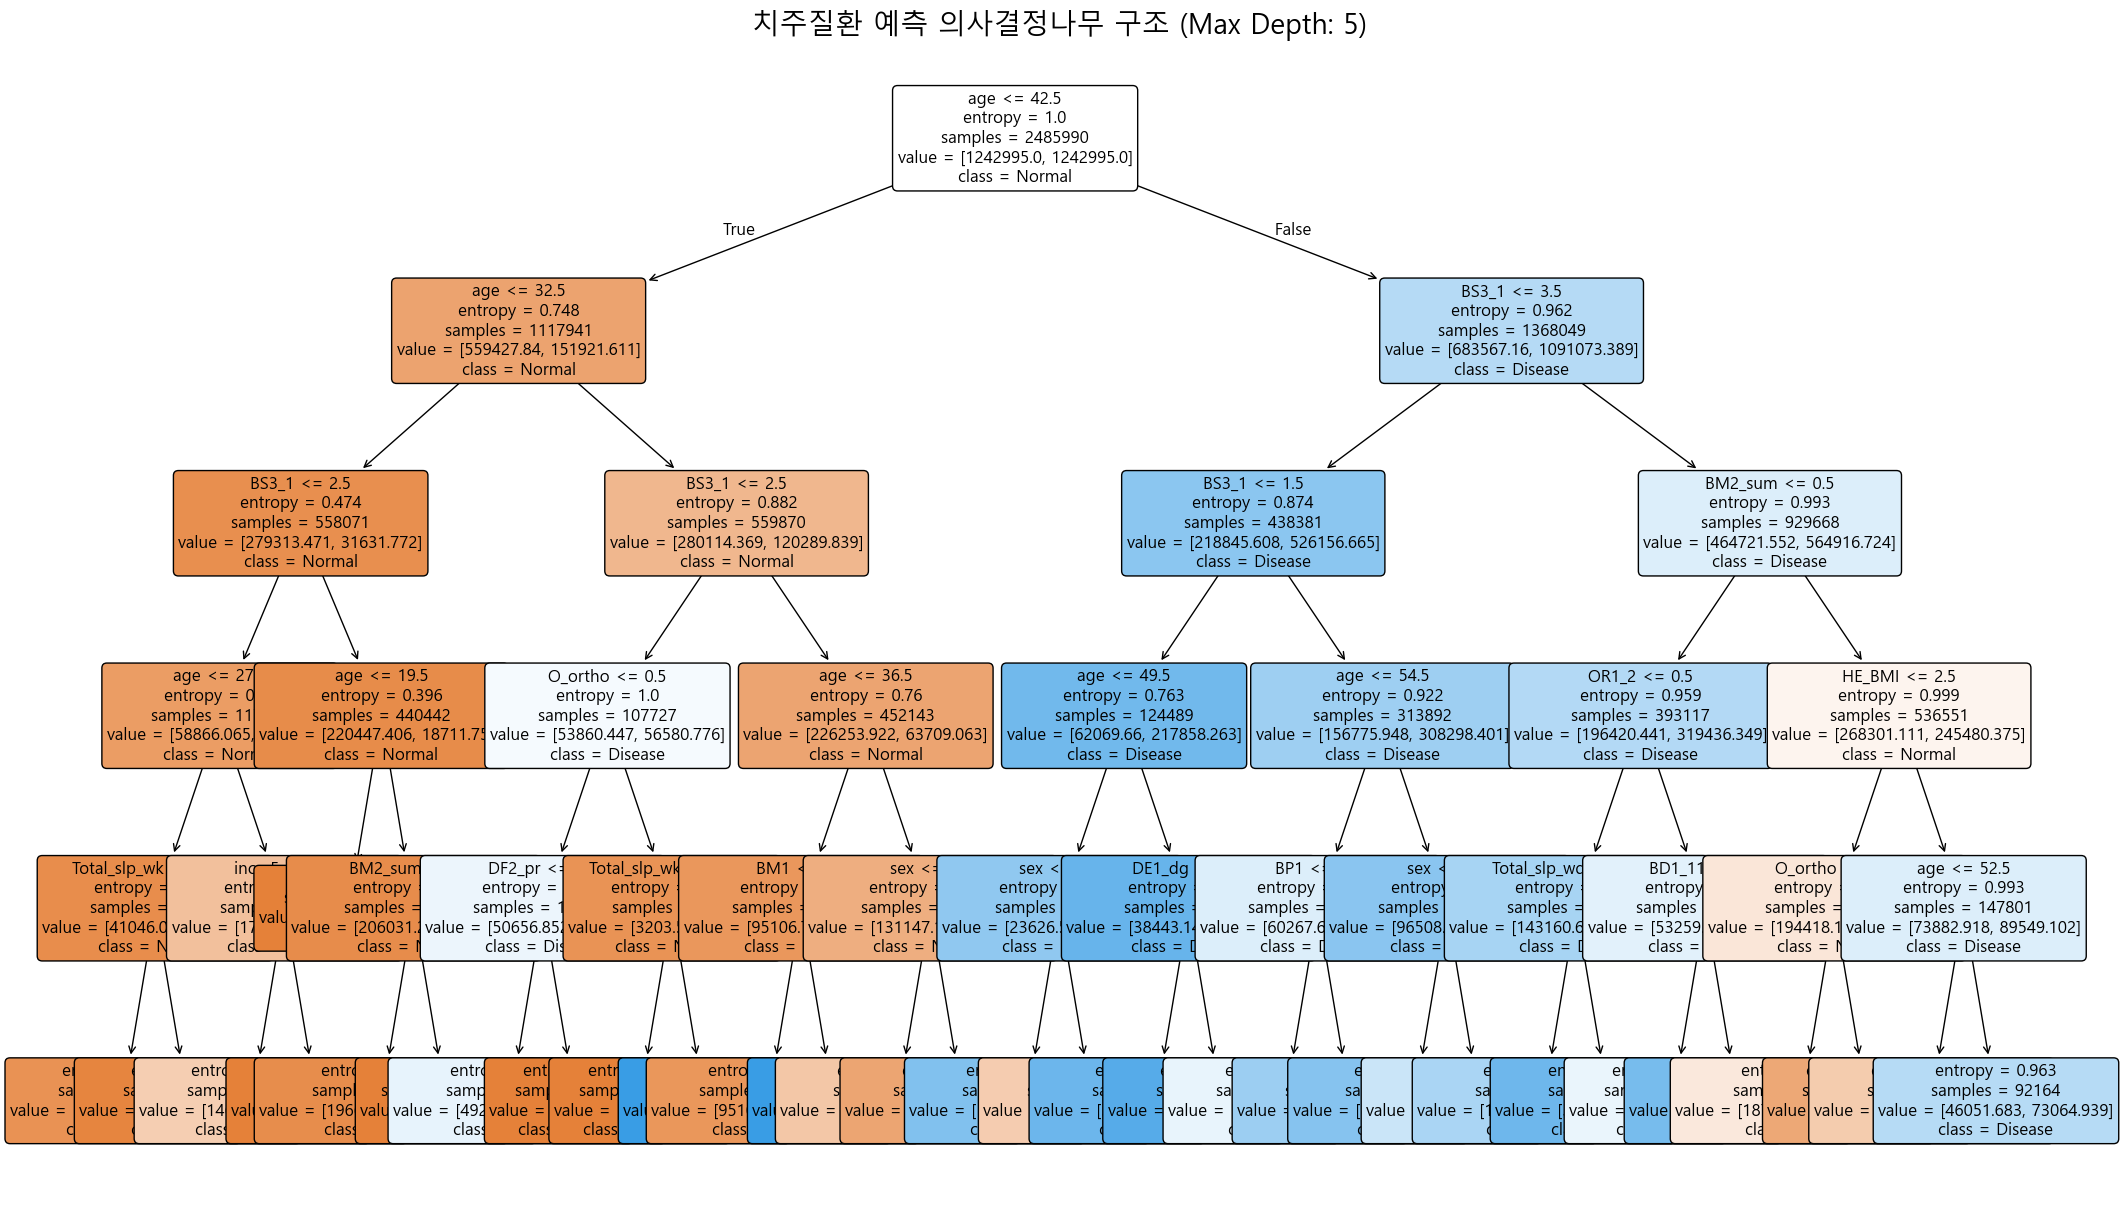

In [37]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import platform

# 1. 한글 폰트 설정 (오류 방지)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 2. 그래프 크기 및 트리 시각화
plt.figure(figsize=(25, 15))

plot_tree(final_model, 
          feature_names=X.columns.tolist(),  
          class_names=['Normal', 'Disease'], # 한글 대신 영문 사용 권장 (오류 방지)
          filled=True,                       
          rounded=True,                      
          fontsize=12)                       

plt.title("치주질환 예측 의사결정나무 구조 (Max Depth: 5)", fontsize=20)

# 3. 그래프 저장 및 출력
# 화면에서 안 보일 경우를 대비해 이미지 파일로도 저장합니다.
plt.savefig('decision_tree_result.png', bbox_inches='tight')
plt.show()

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 최적 하이퍼파라미터 설정 및 특정 Random State 지정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced'
}

target_rs = 152785

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=target_rs)

# --- [추가 작업: 학습 데이터 내 0번 클래스 4배로 늘리기] ---
train_df = pd.concat([X_train, y_train], axis=1)
df_class_0 = train_df[train_df['NO_CPI_34'] == 0]
df_class_1 = train_df[train_df['NO_CPI_34'] == 1]

# 0번 데이터를 4배로 복제 (총 4배)
df_class_0_oversampled = pd.concat([df_class_0] * 400, axis=0)
train_df_oversampled = pd.concat([df_class_0_oversampled, df_class_1], axis=0)

# 데이터 셔플
train_df_oversampled = train_df_oversampled.sample(frac=1, random_state=target_rs).reset_index(drop=True)

X_train_final = train_df_oversampled.drop(columns=['NO_CPI_34'])
y_train_final = train_df_oversampled['NO_CPI_34']
# ---------------------------------------------------------

# 4. 모델 생성 및 학습 (증폭된 데이터 사용)
final_model = DecisionTreeClassifier(**best_params, random_state=target_rs)
final_model.fit(X_train_final, y_train_final)

# 5. 결과 출력 (기본 predict 버전)
final_pred = final_model.predict(X_test)

print("-" * 50)
print(f"적용된 Random State: {target_rs}")
print(f"원본 학습 데이터 0번 클래스 수: {len(df_class_0)}")
print(f"증폭 후 학습 데이터 0번 클래스 수: {len(df_class_0_oversampled)}")
print("-" * 50)
print(f"\n[기본 임계값(0.5) 결과 보고서]")
print(classification_report(y_test, final_pred))

# 6. 결과 출력 (임계값 조정 버전)
# 단순히 predict 하는 대신 모델이 계산한 환자일 확률(probability)을 가져옵니다.
final_proba = final_model.predict_proba(X_test)[:, 1]

# 임계값을 0.5에서 0.65로 상향 (환자라고 확신하는 기준을 높임)
custom_threshold = 0.65
final_pred_custom = (final_proba >= custom_threshold).astype(int)

print(f"\n[임계값 {custom_threshold} 적용 최종 상세 보고서]")
print(classification_report(y_test, final_pred_custom))


--------------------------------------------------
적용된 Random State: 152785
원본 학습 데이터 0번 클래스 수: 6256
증폭 후 학습 데이터 0번 클래스 수: 2502400
--------------------------------------------------

[기본 임계값(0.5) 결과 보고서]
              precision    recall  f1-score   support

         0.0       0.88      0.59      0.71      2038
         1.0       0.49      0.84      0.62       968

    accuracy                           0.67      3006
   macro avg       0.69      0.72      0.67      3006
weighted avg       0.76      0.67      0.68      3006


[임계값 0.65 적용 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.75      0.85      0.80      2038
         1.0       0.57      0.41      0.48       968

    accuracy                           0.71      3006
   macro avg       0.66      0.63      0.64      3006
weighted avg       0.69      0.71      0.69      3006



In [40]:
import sklearn.metrics as metrics

# 7. 정확도(Accuracy) 상세 출력 (경로 직접 지정 방식)
# accuracy_report 대신 metrics.accuracy_score를 사용합니다.
acc_base = metrics.accuracy_score(y_test, final_pred)
acc_custom = metrics.accuracy_score(y_test, final_pred_custom)

print("\n" + "="*50)
print(f"모델 예측 정확도(Accuracy) 결과")
print("-" * 50)
print(f"1. 기본 임계값(0.5) 적용 시 정확도  : {acc_base:.4f} ({acc_base * 100:.2f}%)")
print(f"2. 조정 임계값(0.65) 적용 시 정확도 : {acc_custom:.4f} ({acc_custom * 100:.2f}%)")
print("="*50)


모델 예측 정확도(Accuracy) 결과
--------------------------------------------------
1. 기본 임계값(0.5) 적용 시 정확도  : 0.6720 (67.20%)
2. 조정 임계값(0.65) 적용 시 정확도 : 0.7086 (70.86%)


In [1]:
# 보험 [나이(age), 성별(sex), 당뇨여부(DE1_dg), 정기검진여부(OR1_2)]

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

# --- [수정 부분: 특정 컬럼만 X로 사용] ---
# 요청하신 4가지 변수만 선택합니다.
selected_features = ['age', 'sex', 'DE1_dg', 'OR1_2']
X = df[selected_features]
y = df['NO_CPI_34']
# ---------------------------------------

# 2. 하이퍼파라미터 및 Random State 설정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced'
}
target_rs = 152785

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=target_rs)

# --- [학습 데이터 내 0번 클래스 증폭] ---
train_df = pd.concat([X_train, y_train], axis=1)
df_class_0 = train_df[train_df['NO_CPI_34'] == 0]
df_class_1 = train_df[train_df['NO_CPI_34'] == 1]

# 기존 코드의 로직대로 0번 데이터를 400배 복제 (필요에 따라 배율 조정 권장)
df_class_0_oversampled = pd.concat([df_class_0] * 400, axis=0)
train_df_oversampled = pd.concat([df_class_0_oversampled, df_class_1], axis=0)

# 데이터 셔플
train_df_oversampled = train_df_oversampled.sample(frac=1, random_state=target_rs).reset_index(drop=True)

X_train_final = train_df_oversampled.drop(columns=['NO_CPI_34'])
y_train_final = train_df_oversampled['NO_CPI_34']

# 4. 모델 생성 및 학습
final_model = DecisionTreeClassifier(**best_params, random_state=target_rs)
final_model.fit(X_train_final, y_train_final)

# 5. 결과 출력 (기본 임계값 0.5)
final_pred = final_model.predict(X_test)

print("=" * 60)
print(f"사용된 피처: {selected_features}")
print(f"적용된 Random State: {target_rs}")
print("-" * 60)
print("\n[기본 임계값(0.5) precision, recall, f1-score]")
print(classification_report(y_test, final_pred))

# 6. 결과 출력 (임계값 0.65 조정 버전)
final_proba = final_model.predict_proba(X_test)[:, 1]
custom_threshold = 0.65
final_pred_custom = (final_proba >= custom_threshold).astype(int)

print(f"\n[임계값 {custom_threshold} 적용 precision, recall, f1-score]")
print(classification_report(y_test, final_pred_custom))

사용된 피처: ['age', 'sex', 'DE1_dg', 'OR1_2']
적용된 Random State: 152785
------------------------------------------------------------

[기본 임계값(0.5) precision, recall, f1-score]
              precision    recall  f1-score   support

         0.0       0.86      0.64      0.74      2038
         1.0       0.51      0.79      0.62       968

    accuracy                           0.69      3006
   macro avg       0.69      0.71      0.68      3006
weighted avg       0.75      0.69      0.70      3006


[임계값 0.65 적용 precision, recall, f1-score]
              precision    recall  f1-score   support

         0.0       0.75      0.83      0.79      2038
         1.0       0.55      0.43      0.48       968

    accuracy                           0.70      3006
   macro avg       0.65      0.63      0.63      3006
weighted avg       0.69      0.70      0.69      3006



In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score  # accuracy_score 추가

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

# --- [특정 컬럼만 X로 사용] ---
selected_features = ['age', 'sex', 'DE1_dg', 'OR1_2']
X = df[selected_features]
y = df['NO_CPI_34']

# 2. 하이퍼파라미터 및 Random State 설정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced'
}
target_rs = 152785

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=target_rs)

# --- [학습 데이터 내 0번 클래스 증폭] ---
train_df = pd.concat([X_train, y_train], axis=1)
df_class_0 = train_df[train_df['NO_CPI_34'] == 0]
df_class_1 = train_df[train_df['NO_CPI_34'] == 1]

df_class_0_oversampled = pd.concat([df_class_0] * 400, axis=0)
train_df_oversampled = pd.concat([df_class_0_oversampled, df_class_1], axis=0)

train_df_oversampled = train_df_oversampled.sample(frac=1, random_state=target_rs).reset_index(drop=True)

X_train_final = train_df_oversampled.drop(columns=['NO_CPI_34'])
y_train_final = train_df_oversampled['NO_CPI_34']

# 4. 모델 생성 및 학습
final_model = DecisionTreeClassifier(**best_params, random_state=target_rs)
final_model.fit(X_train_final, y_train_final)

# 5. 결과 출력 (기본 임계값 0.5)
final_pred = final_model.predict(X_test)
acc_base = accuracy_score(y_test, final_pred) # 정확도 계산

print("=" * 60)
print(f"사용된 피처: {selected_features}")
print(f"적용된 Random State: {target_rs}")
print("-" * 60)
print(f"\n[기본 임계값(0.5) 결과]")
print(f"전체 정확도(Accuracy): {acc_base:.4f}") # 정확도 출력 추가
print(classification_report(y_test, final_pred))

# 6. 결과 출력 (임계값 0.65 조정 버전)
final_proba = final_model.predict_proba(X_test)[:, 1]
custom_threshold = 0.65
final_pred_custom = (final_proba >= custom_threshold).astype(int)
acc_custom = accuracy_score(y_test, final_pred_custom) # 정확도 계산

print(f"\n[임계값 {custom_threshold} 적용 결과]")
print(f"전체 정확도(Accuracy): {acc_custom:.4f}") # 정확도 출력 추가
print(classification_report(y_test, final_pred_custom))

사용된 피처: ['age', 'sex', 'DE1_dg', 'OR1_2']
적용된 Random State: 152785
------------------------------------------------------------

[기본 임계값(0.5) 결과]
전체 정확도(Accuracy): 0.6876
              precision    recall  f1-score   support

         0.0       0.86      0.64      0.74      2038
         1.0       0.51      0.79      0.62       968

    accuracy                           0.69      3006
   macro avg       0.69      0.71      0.68      3006
weighted avg       0.75      0.69      0.70      3006


[임계값 0.65 적용 결과]
전체 정확도(Accuracy): 0.7013
              precision    recall  f1-score   support

         0.0       0.75      0.83      0.79      2038
         1.0       0.55      0.43      0.48       968

    accuracy                           0.70      3006
   macro avg       0.65      0.63      0.63      3006
weighted avg       0.69      0.70      0.69      3006

